In [1]:
# 1. Mount Google Drive so Colab can read your files
from google.colab import drive
import os

print("Requesting access to Google Drive...")
drive.mount('/content/drive')

# 2. Define the path to the folder you just created
data_path = '/content/drive/MyDrive/ADNI_Project_Data/'

# 3. List all the files in the folder to make sure Colab can see them
print("\n--- Files found in ADNI_Project_Data ---")
try:
    files = os.listdir(data_path)
    for file in files:
        print(f"- {file}")
except FileNotFoundError:
    print("ERROR: Could not find the folder. Make sure it is named exactly 'ADNI_Project_Data' and is in your main Drive.")

Requesting access to Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- Files found in ADNI_Project_Data ---
- ADNI_Gene_Expression_Profile.csv
- ADNI_Gene_Expression_Profile_DICT.csv
- ADNI_Microarry_Gene_Expression_Methods_Final_20150427.pdf
- ADNI_CSF_sTREM2_PGRN_Methods_20180316.pdf
- ADNI_HAASS_WASHU_LAB_12Jul2026.csv
- UPENN_PLASMA_FUJIREBIO_QUANTERIX_12Jul2026.csv
- ADNI_UPENN_PLASMA_FUJIREBIO_QUANTERIX_METHODS_20260209.pdf
- UPENNBIOMK_ROCHE_ELECSYS_12Jul2026.csv
- ADNIMERGE_02Jun2026(1).csv
- ML_Ready_Blood_to_sTREM2.csv
- Untitled document.gdoc
- WGCNA_Gene_Modules.csv
- WGCNA_Module_Eigengenes.csv
- Final_SHAP_Summary.pdf
- Figure_4_Pred_vs_Obs.pdf
- Figure_6_SHAP_Dependence_Black.pdf
- Figure_7_Incremental_R2.pdf
- Figure_3_sTREM2_Distribution.pdf
- XGBoost_Feature_Importance.pdf
- Figure_1_Study_Workflow.pdf
- Figure_1_Study_Workflow.png
- Strict_Test_Set_Prodromal.csv
- X_tr

In [2]:
import pandas as pd
import numpy as np
import gc

# 1. Load the raw Gene Expression Data
file_path = '/content/drive/MyDrive/ADNI_Project_Data/ADNI_Gene_Expression_Profile.csv'
print("Loading microarray data into memory (this may take a moment)...")
gene_data = pd.read_csv(file_path, low_memory=False)

# 2. Isolate the numeric gene expressions
metadata_cols = ['RID', 'VISCODE', 'Phase', 'Phase_Dataset']
available_meta = [col for col in metadata_cols if col in gene_data.columns]
numeric_genes = gene_data.drop(columns=available_meta)

print("Scrubbing dirty data (forcing text to numeric)...")
# This forces all columns to numbers. Any text (like "NA") gets turned into NaN
numeric_genes = numeric_genes.apply(pd.to_numeric, errors='coerce')

# Fill those missing NaN values with 0 so the math doesn't break
numeric_genes = numeric_genes.fillna(0)

print(f"Data cleaned: {gene_data.shape[0]} patients, {numeric_genes.shape[1]} genes.")

# 3. Shift and Scale to avoid negative probabilities
print("Normalizing patient profiles into probability distributions...")
min_vals = numeric_genes.min(axis=1)
# Shift all values above zero
shifted_genes = numeric_genes.sub(min_vals, axis=0)
# Add a microscopic constant to prevent log(0) crashes
shifted_genes = shifted_genes + 1e-9

# 4. Convert to probability distribution (each patient's row now sums to 1.0)
row_sums = shifted_genes.sum(axis=1)
prob_matrix = shifted_genes.div(row_sums, axis=0)

# 5. Calculate the Gibbs-Shannon Entropy: S = - sum(P * ln(P))
print("Calculating Gibbs-Shannon Entropy index...")
entropy_values = -np.sum(prob_matrix * np.log(prob_matrix), axis=1)

# 6. Create the final output dataframe
patient_entropy = pd.DataFrame({
    'RID': gene_data['RID'] if 'RID' in gene_data.columns else gene_data.index,
    'VISCODE': gene_data['VISCODE'] if 'VISCODE' in gene_data.columns else 'bl',
    'Transcriptomic_Entropy': entropy_values
})

# Flush the heavy matrices from RAM
del numeric_genes, shifted_genes, prob_matrix
gc.collect()

print("\nFirst 5 Patients' Entropy Scores:")
print(patient_entropy.head())
print("\nStep 1 Complete. Memory cleared.")

Loading microarray data into memory (this may take a moment)...
Scrubbing dirty data (forcing text to numeric)...
Data cleaned: 49394 patients, 747 genes.
Normalizing patient profiles into probability distributions...
Calculating Gibbs-Shannon Entropy index...

First 5 Patients' Entropy Scores:
   RID VISCODE  Transcriptomic_Entropy
0    0      bl                6.616065
1    1      bl                6.616065
2    2      bl                6.611554
3    3      bl                6.554211
4    4      bl                6.605227

Step 1 Complete. Memory cleared.


In [3]:
!pip install lifelines -q

import pandas as pd
import numpy as np
from lifelines import CoxPHFitter

# 1. Load the Clinical Merge File
print("Loading ADNIMERGE clinical timelines...")
merge_path = '/content/drive/MyDrive/ADNI_Project_Data/ADNIMERGE_02Jun2026(1).csv'
adnimerge = pd.read_csv(merge_path, low_memory=False)

# 2. Isolate Baseline Entropy and Clinical Data
base_entropy = patient_entropy[patient_entropy['VISCODE'] == 'bl'].copy()
base_clin = adnimerge[adnimerge['VISCODE'] == 'bl'].copy()

# ADNI codes MCI in a few ways depending on the phase (LMCI, EMCI, MCI)
base_clin = base_clin[base_clin['DX_bl'].isin(['LMCI', 'EMCI', 'MCI'])]

# Merge the physical math with the clinical reality
df_merged = pd.merge(base_entropy, base_clin, on='RID', how='inner')
print(f"Isolated {df_merged.shape[0]} baseline MCI patients for longitudinal tracking.")

# 3. Build the Survival Timelines (Time and Event)
print("Scanning longitudinal records for Dementia conversion...")
longitudinal_data = adnimerge[adnimerge['RID'].isin(df_merged['RID'])].copy()
longitudinal_data['Years_bl'] = pd.to_numeric(longitudinal_data['Years_bl'], errors='coerce')

events = []
times = []

for rid in df_merged['RID']:
    # Get all visits for this patient, sorted by time
    patient_visits = longitudinal_data[longitudinal_data['RID'] == rid].dropna(subset=['DX', 'Years_bl']).sort_values('Years_bl')

    if patient_visits.empty:
        events.append(0)
        times.append(0)
        continue

    # Check if they ever transitioned to full Dementia
    converted = patient_visits[patient_visits['DX'] == 'Dementia']

    if not converted.empty:
        # Event = 1 (They converted). Time = Years until conversion.
        events.append(1)
        times.append(converted.iloc[0]['Years_bl'])
    else:
        # Event = 0 (Remained stable). Time = Years of follow-up.
        events.append(0)
        times.append(patient_visits.iloc[-1]['Years_bl'])

df_merged['Event'] = events
df_merged['Time'] = times

# Filter out anyone with zero follow-up time
df_survival = df_merged[df_merged['Time'] > 0].copy()
print(f"Final Survival Cohort: {df_survival.shape[0]} patients tracked over time.")

# 4. Run the Cox Proportional Hazards Model
print("\nFitting thermodynamic model to clinical reality...")
# Select our predictors
cph_data = df_survival[['Time', 'Event', 'Transcriptomic_Entropy', 'AGE', 'PTGENDER']].copy()
# Format gender for the math model (Male=0, Female=1)
cph_data['PTGENDER'] = (cph_data['PTGENDER'] == 'Female').astype(int)
cph_data = cph_data.dropna()

cph = CoxPHFitter()
cph.fit(cph_data, duration_col='Time', event_col='Event')

# Display the crucial statistics
print("\n--- COX PROPORTIONAL HAZARDS RESULTS ---")
cph.print_summary(columns=['coef', 'exp(coef)', 'p', 'se(coef)'])

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 10.1 MB/s eta 0:00:00
Loading ADNIMERGE clinical timelines...
Isolated 1113 baseline MCI patients for longitudinal tracking.
Scanning longitudinal records for Dementia conversion...
Final Survival Cohort: 988 patients tracked over time.

Fitting thermodynamic model to clinical reality...

--- COX PROPORTIONAL HAZARDS RESULTS ---


/usr/local/lib/python3.12/dist-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['Transcriptomic_Entropy'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


<lifelines.CoxPHFitter: fitted with 985 total observations, 606 right-censored observations>
             duration col = 'Time'
                event col = 'Event'
      baseline estimation = breslow
   number of observations = 985
number of events observed = 379
   partial log-likelihood = -2343.33
         time fit was run = 2026-08-09 18:50:22 UTC

---
                         coef exp(coef)  se(coef)      p
covariate                                               
Transcriptomic_Entropy -21.48      0.00     14.31   0.13
AGE                      0.03      1.03      0.01 <0.005
PTGENDER                 0.04      1.04      0.11   0.71
---
Concordance = 0.55
Partial AIC = 4692.66
log-likelihood ratio test = 18.33 on 3 df
-log2(p) of ll-ratio test = 11.38

In [4]:
from scipy.stats import zscore

print("Applying Z-score transformation to Transcriptomic Entropy...")

# Create a fresh copy of our data to keep things clean
cph_data_scaled = cph_data.copy()

# Standardize the entropy values (Mean = 0, Standard Deviation = 1)
cph_data_scaled['Transcriptomic_Entropy_Z'] = zscore(cph_data_scaled['Transcriptomic_Entropy'])

# Drop the old microscopic column so the model only sees the scaled version
cph_data_scaled = cph_data_scaled.drop(columns=['Transcriptomic_Entropy'])

print("Refitting the Cox Proportional Hazards Model...")
cph_scaled = CoxPHFitter()
cph_scaled.fit(cph_data_scaled, duration_col='Time', event_col='Event')

# Display the true statistical signal
print("\n--- STANDARDIZED COX PROPORTIONAL HAZARDS RESULTS ---")
cph_scaled.print_summary(columns=['coef', 'exp(coef)', 'p', 'se(coef)'])

Applying Z-score transformation to Transcriptomic Entropy...
Refitting the Cox Proportional Hazards Model...

--- STANDARDIZED COX PROPORTIONAL HAZARDS RESULTS ---


<lifelines.CoxPHFitter: fitted with 985 total observations, 606 right-censored observations>
             duration col = 'Time'
                event col = 'Event'
      baseline estimation = breslow
   number of observations = 985
number of events observed = 379
   partial log-likelihood = -2343.33
         time fit was run = 2026-08-09 18:50:22 UTC

---
                          coef exp(coef)  se(coef)      p
covariate                                                
AGE                       0.03      1.03      0.01 <0.005
PTGENDER                  0.04      1.04      0.11   0.71
Transcriptomic_Entropy_Z -0.07      0.93      0.05   0.13
---
Concordance = 0.55
Partial AIC = 4692.66
log-likelihood ratio test = 18.33 on 3 df
-log2(p) of ll-ratio test = 11.38

In [5]:
import pandas as pd
import numpy as np
import gc

# 1. Load the Gene Expression Data and the WGCNA Module Map
print("Loading microarray data and module assignments...")
expr_path = '/content/drive/MyDrive/ADNI_Project_Data/ADNI_Gene_Expression_Profile.csv'
modules_path = '/content/drive/MyDrive/ADNI_Project_Data/WGCNA_Gene_Modules.csv'

gene_data = pd.read_csv(expr_path, low_memory=False)
module_df = pd.read_csv(modules_path)

# 2. Scrub the expression data
metadata_cols = ['RID', 'VISCODE', 'Phase', 'Phase_Dataset']
available_meta = [col for col in metadata_cols if col in gene_data.columns]
numeric_genes = gene_data.drop(columns=available_meta).apply(pd.to_numeric, errors='coerce').fillna(0)

# Map the unique colors
module_colors = module_df['moduleColors'].unique()
print(f"Mapped {len(module_colors)} distinct immune modules based on WGCNA colors.")

# 3. Initialize the Localized Entropy DataFrame
localized_entropy = pd.DataFrame({
    'RID': gene_data['RID'] if 'RID' in gene_data.columns else gene_data.index,
    'VISCODE': gene_data['VISCODE'] if 'VISCODE' in gene_data.columns else 'bl'
})

# 4. Calculate Thermodynamic Entropy per Module
print("Executing localized entropy math for each colored pathway. Please wait...")

for color in sorted(module_colors):
    # Find the specific genes for this colored pathway
    mod_genes = module_df[module_df['moduleColors'] == color]['Unnamed: 0'].values
    valid_genes = [g for g in mod_genes if g in numeric_genes.columns]

    if len(valid_genes) < 2:
        continue # Skip if a module lacks enough genes to form a distribution

    mod_data = numeric_genes[valid_genes]

    # Shift and normalize into a probability distribution
    min_vals = mod_data.min(axis=1)
    shifted = mod_data.sub(min_vals, axis=0) + 1e-9

    row_sums = shifted.sum(axis=1)
    prob_matrix = shifted.div(row_sums, axis=0)

    # Gibbs-Shannon Entropy
    entropy = -np.sum(prob_matrix * np.log(prob_matrix), axis=1)

    # Store the result
    localized_entropy[f'Entropy_{color}'] = entropy

# Flush the heavy arrays out of memory
del numeric_genes, gene_data
gc.collect()

print("\nExtraction complete. Memory cleared.")
print("First 5 patients' localized module entropies:")
print(localized_entropy.iloc[:5, :6])

Loading microarray data and module assignments...
Mapped 3 distinct immune modules based on WGCNA colors.
Executing localized entropy math for each colored pathway. Please wait...

Extraction complete. Memory cleared.
First 5 patients' localized module entropies:
   RID VISCODE
0    0      bl
1    1      bl
2    2      bl
3    3      bl
4    4      bl


In [6]:
import pandas as pd
modules_path = '/content/drive/MyDrive/ADNI_Project_Data/WGCNA_Gene_Modules.csv'
module_df = pd.read_csv(modules_path)

print("Exact column names:", module_df.columns.tolist())
print("\nFirst few rows:")
print(module_df.head())

Exact column names: ['Unnamed: 0', 'moduleColors']

First few rows:
      Unnamed: 0 moduleColors
0  11757733_s_at     darkgrey
1  11754194_s_at     darkgrey
2  11716411_x_at     darkgrey
3  11757857_s_at     darkgrey
4  11756083_x_at     darkgrey


In [7]:
import pandas as pd

# 1. Peek at the blood expression file's headers
expr_path = '/content/drive/MyDrive/ADNI_Project_Data/ADNI_Gene_Expression_Profile.csv'
gene_data = pd.read_csv(expr_path, nrows=0) # We only need the headers, not the data

# Skip the first few metadata columns (RID, VISCODE) to see the actual genes
print("First 10 gene columns in the Blood Expression File:")
print(list(gene_data.columns)[4:14])

# 2. Peek at the WGCNA file
modules_path = '/content/drive/MyDrive/ADNI_Project_Data/WGCNA_Gene_Modules.csv'
module_df = pd.read_csv(modules_path)

print("\nFirst 10 gene names in the WGCNA Module File:")
print(module_df['Unnamed: 0'].head(10).tolist())

First 10 gene columns in the Blood Expression File:
['ADNI2', 'ADNI2.1', 'ADNIGO.1', 'ADNI2.2', 'ADNI2.3', 'ADNI2.4', 'ADNIGO.2', 'ADNI2.5', 'ADNI2.6', 'ADNIGO.3']

First 10 gene names in the WGCNA Module File:
['11757733_s_at', '11754194_s_at', '11716411_x_at', '11757857_s_at', '11756083_x_at', '11732801_at', '11755998_x_at', '11760799_x_at', '11720807_x_at', '11726814_x_at']


In [8]:
import pandas as pd
import numpy as np
import gc

print("Loading microarray data (this will take a moment)...")
expr_path = '/content/drive/MyDrive/ADNI_Project_Data/ADNI_Gene_Expression_Profile.csv'
gene_data = pd.read_csv(expr_path, low_memory=False)

# 1. Flip the Matrix
print("Flipping matrix 90 degrees (Transposing)...")
# The very first column holds our Gene Probe IDs. We set it as the index before flipping.
first_col = gene_data.columns[0]
gene_data.set_index(first_col, inplace=True)

# Transpose! Now Rows = Patients, Columns = Genes
patient_data = gene_data.T

# Scrub to pure numeric
patient_data = patient_data.apply(pd.to_numeric, errors='coerce').fillna(0)
print(f"Corrected Shape: {patient_data.shape[0]} patients, {patient_data.shape[1]} genes.")

# 2. Load the WGCNA Modules
modules_path = '/content/drive/MyDrive/ADNI_Project_Data/WGCNA_Gene_Modules.csv'
module_df = pd.read_csv(modules_path)
module_colors = module_df['moduleColors'].unique()
print(f"Found {len(module_colors)} immune modules: {module_colors}")

# 3. Calculate Localized Entropy
print("Calculating thermodynamic entropy for each module...")
# We use the patient IDs (which are now our index)
localized_entropy = pd.DataFrame(index=patient_data.index)

for color in sorted(module_colors):
    # Find the specific genes for this colored pathway
    mod_genes = module_df[module_df['moduleColors'] == color]['Unnamed: 0'].values

    # Only keep the ones that actually exist in our flipped matrix
    valid_genes = [g for g in mod_genes if g in patient_data.columns]

    if len(valid_genes) < 2:
        continue

    mod_data = patient_data[valid_genes]

    # Standard probability shift
    min_vals = mod_data.min(axis=1)
    shifted = mod_data.sub(min_vals, axis=0) + 1e-9

    row_sums = shifted.sum(axis=1)
    prob_matrix = shifted.div(row_sums, axis=0)

    # Calculate Gibbs-Shannon Entropy
    entropy = -np.sum(prob_matrix * np.log(prob_matrix), axis=1)
    localized_entropy[f'Entropy_{color}'] = entropy

# Reset index so Patient IDs become a normal column we can merge later
localized_entropy.reset_index(inplace=True)
localized_entropy.rename(columns={'index': 'Patient_ID'}, inplace=True)

del patient_data, gene_data
gc.collect()

print("\nSuccess! First 5 patients' localized entropies:")
print(localized_entropy.head())

Loading microarray data (this will take a moment)...
Flipping matrix 90 degrees (Transposing)...
Corrected Shape: 747 patients, 49394 genes.
Found 3 immune modules: ['darkgrey' 'black' 'dimgrey']
Calculating thermodynamic entropy for each module...

Success! First 5 patients' localized entropies:
   Patient_ID  Entropy_black  Entropy_darkgrey  Entropy_dimgrey
0  Unnamed: 1       8.354910          8.636930         4.727388
1  Unnamed: 2       8.354910          8.636930         4.727388
2      ADNIGO       8.271636          8.540039         4.563569
3       ADNI2       8.292142          8.537056         4.550841
4     ADNI2.1       8.276451          8.525160         4.572460


In [9]:
import pandas as pd
dict_path = '/content/drive/MyDrive/ADNI_Project_Data/ADNI_Gene_Expression_Profile_DICT.csv'
meta_dict = pd.read_csv(dict_path)
print(meta_dict.head(10))

           Variable                                        Description  \
0             Phase              Phase of ADNI at which visit occurred   
1             Visit        Visit at which PaxGene sample was collected   
2         SubjectID  Subject ID including site; first three numbers...   
3           260/280                                      260/280 ratio   
4           260/230                                      260/230 ratio   
5               RIN                         RNA Integrity Number (RIN)   
6        Affy Plate                                       Plate number   
7  YearofCollection         Year at which PaxGene sample was collected   

                                               Value  
0                                                NaN  
1  bl/v03 = baseline; m03 = 3-month visit; m12 = ...  
2                                         ZZZ_S_XXXX  
3                                                NaN  
4                                                NaN  
5  

In [10]:
import pandas as pd
ml_path = '/content/drive/MyDrive/ADNI_Project_Data/ML_Ready_Blood_to_sTREM2.csv'
ml_data = pd.read_csv(ml_path, nrows=5)
print(ml_data.columns.tolist())

['Visit', 'SubjectID', '260/280', '260/230', 'RIN', 'Affy Plate', 'YearofCollection', 'ProbeSet', '11715100_at', '11715101_s_at', '11715102_x_at', '11715103_x_at', '11715104_s_at', '11715105_at', '11715106_x_at', '11715107_s_at', '11715108_x_at', '11715109_at', '11715110_at', '11715111_s_at', '11715112_at', '11715113_x_at', '11715114_x_at', '11715115_s_at', '11715116_s_at', '11715117_x_at', '11715118_s_at', '11715119_s_at', '11715120_s_at', '11715121_s_at', '11715122_at', '11715123_s_at', '11715124_s_at', '11715125_at', '11715126_s_at', '11715127_s_at', '11715128_s_at', '11715129_s_at', '11715130_s_at', '11715131_s_at', '11715132_x_at', '11715133_s_at', '11715134_s_at', '11715135_s_at', '11715136_at', '11715137_s_at', '11715138_s_at', '11715139_x_at', '11715140_s_at', '11715141_s_at', '11715142_s_at', '11715143_s_at', '11715144_s_at', '11715145_s_at', '11715146_x_at', '11715147_at', '11715148_s_at', '11715149_x_at', '11715150_s_at', '11715151_x_at', '11715152_at', '11715153_s_at', '117

In [12]:
import pandas as pd

print("Bridging Lab IDs to Clinical RIDs (Forced Alignment)...")
ml_path = '/content/drive/MyDrive/ADNI_Project_Data/ML_Ready_Blood_to_sTREM2.csv'
mapping_df = pd.read_csv(ml_path, usecols=['SubjectID', 'RID']).drop_duplicates()

# 1. Force formatting on both files (lowercase, no spaces)
mapping_df['Clean_ID'] = mapping_df['SubjectID'].astype(str).str.strip().str.lower()
localized_entropy['Clean_ID'] = localized_entropy['Patient_ID'].astype(str).str.strip().str.lower()

# 2. Merge on the cleaned keys
print("Executing fuzzy merge...")
final_entropy_df = pd.merge(
    localized_entropy,
    mapping_df,
    on='Clean_ID',
    how='inner'
)

# 3. Clean up the final table
final_entropy_df = final_entropy_df.drop(columns=['Patient_ID', 'SubjectID', 'Clean_ID'])
# Reorder so RID is the first column
cols = ['RID'] + [col for col in final_entropy_df if col != 'RID']
final_entropy_df = final_entropy_df[cols]

print(f"Successfully mapped {final_entropy_df.shape[0]} patients to RIDs.")

if final_entropy_df.shape[0] > 0:
    final_entropy_df.to_csv('/content/drive/MyDrive/ADNI_Project_Data/FINAL_Localized_Entropy_Scores.csv', index=False)
    print("\nMapping complete. Data saved as FINAL_Localized_Entropy_Scores.csv")
    print(final_entropy_df.head())
else:
    print("\nCRITICAL FAILURE: The lab IDs and the RIDs are completely disjointed.")
    print("Sample from Entropy File:", localized_entropy['Clean_ID'].head(3).tolist())
    print("Sample from ML File:", mapping_df['Clean_ID'].head(3).tolist())

Bridging Lab IDs to Clinical RIDs (Forced Alignment)...
Executing fuzzy merge...
Successfully mapped 0 patients to RIDs.

CRITICAL FAILURE: The lab IDs and the RIDs are completely disjointed.
Sample from Entropy File: ['unnamed: 1', 'unnamed: 2', 'adnigo']
Sample from ML File: ['037_s_4410', '006_s_4153', '099_s_4205']


In [11]:
import pandas as pd

expr_path = '/content/drive/MyDrive/ADNI_Project_Data/ADNI_Gene_Expression_Profile.csv'

# Pull just the top corner of the massive spreadsheet
print("X-Raying the top rows of the ADNI Microarray file...")
peek_df = pd.read_csv(expr_path, nrows=15, usecols=[0, 1, 2, 3, 4])

print("\n--- TOP 15 ROWS ---")
print(peek_df)

X-Raying the top rows of the ADNI Microarray file...

--- TOP 15 ROWS ---
               Phase Unnamed: 1         Unnamed: 2      ADNIGO       ADNI2
0              Visit        NaN                NaN         m48         v03
1          SubjectID        NaN                NaN  116_S_1249  037_S_4410
2            260/280        NaN                NaN        2.05        2.07
3            260/230        NaN                NaN        0.55        1.54
4                RIN        NaN                NaN         7.7         7.6
5         Affy Plate        NaN                NaN           7           3
6   YearofCollection        NaN                NaN        2011        2012
7           ProbeSet  LocusLink             Symbol         NaN         NaN
8        11715100_at    LOC8355           HIST1H3G       2.237       2.294
9      11715101_s_at    LOC8355           HIST1H3G       2.624       2.416
10     11715102_x_at    LOC8355           HIST1H3G       1.873       1.884
11     11715103_x_at  LOC1

In [13]:
import pandas as pd
import numpy as np
import gc

print("Executing surgical extraction of ADNI microarray data...")
expr_path = '/content/drive/MyDrive/ADNI_Project_Data/ADNI_Gene_Expression_Profile.csv'

# 1. Pull the TRUE Patient IDs from Row 1
raw_data = pd.read_csv(expr_path, low_memory=False)

# Grab row 1 (which holds the SubjectIDs)
true_ids = raw_data.iloc[1].values

# 2. Slice off the top 7 rows of metadata to isolate pure gene numbers
# We keep the first column (index 0) because it holds the Gene Probe names
numeric_matrix = raw_data.iloc[8:, :].copy()

# Set the true SubjectIDs as the column headers
numeric_matrix.columns = true_ids
# Set the Gene Probe IDs as the row index
numeric_matrix.set_index(numeric_matrix.columns[0], inplace=True)

# 3. Transpose the matrix (Rows = Patients, Columns = Genes)
patient_data = numeric_matrix.T

# Scrub to pure numeric and drop any rows that ended up with 'NaN' as an ID
patient_data = patient_data.apply(pd.to_numeric, errors='coerce').fillna(0)
patient_data = patient_data[patient_data.index.notna()]

print(f"Cleaned Matrix Ready: {patient_data.shape[0]} patients, {patient_data.shape[1]} genes.")

# 4. Load the WGCNA Modules
modules_path = '/content/drive/MyDrive/ADNI_Project_Data/WGCNA_Gene_Modules.csv'
module_df = pd.read_csv(modules_path)
module_colors = module_df['moduleColors'].unique()

# 5. Calculate Localized Entropy
print("Calculating localized thermodynamic entropy...")
localized_entropy = pd.DataFrame(index=patient_data.index)

for color in sorted(module_colors):
    mod_genes = module_df[module_df['moduleColors'] == color]['Unnamed: 0'].values
    valid_genes = [g for g in mod_genes if g in patient_data.columns]

    if len(valid_genes) < 2:
        continue

    mod_data = patient_data[valid_genes]

    # Probability shift and Gibbs-Shannon S = - sum(P * ln(P))
    min_vals = mod_data.min(axis=1)
    shifted = mod_data.sub(min_vals, axis=0) + 1e-9
    prob_matrix = shifted.div(shifted.sum(axis=1), axis=0)
    localized_entropy[f'Entropy_{color}'] = -np.sum(prob_matrix * np.log(prob_matrix), axis=1)

# Format the index back to a standard column
localized_entropy.reset_index(inplace=True)
localized_entropy.rename(columns={'index': 'SubjectID'}, inplace=True)

del patient_data, numeric_matrix, raw_data
gc.collect()

# 6. Bridge to RIDs for survival analysis
ml_path = '/content/drive/MyDrive/ADNI_Project_Data/ML_Ready_Blood_to_sTREM2.csv'
mapping_df = pd.read_csv(ml_path, usecols=['SubjectID', 'RID']).drop_duplicates()

# Clean formatting on both sides just to be safe
mapping_df['Clean_ID'] = mapping_df['SubjectID'].astype(str).str.strip().str.lower()
localized_entropy['Clean_ID'] = localized_entropy['SubjectID'].astype(str).str.strip().str.lower()

final_entropy_df = pd.merge(localized_entropy, mapping_df, on='Clean_ID', how='inner')
final_entropy_df = final_entropy_df.drop(columns=['SubjectID_x', 'SubjectID_y', 'Clean_ID'])
cols = ['RID'] + [col for col in final_entropy_df if col != 'RID']
final_entropy_df = final_entropy_df[cols]

final_entropy_df.to_csv('/content/drive/MyDrive/ADNI_Project_Data/FINAL_Localized_Entropy_Scores.csv', index=False)
print(f"\nSUCCESS! Mapped {final_entropy_df.shape[0]} patients to RIDs.")
print(final_entropy_df.head())

Executing surgical extraction of ADNI microarray data...
Cleaned Matrix Ready: 744 patients, 49386 genes.
Calculating localized thermodynamic entropy...

SUCCESS! Mapped 475 patients to RIDs.
      RID  Entropy_black  Entropy_darkgrey  Entropy_dimgrey
0  4410.0       8.292142          8.537056         4.550841
1  4153.0       8.276451          8.525160         4.572460
2  4205.0       8.278141          8.534131         4.569385
3  4467.0       8.268928          8.527706         4.593779
4  2374.0       8.258766          8.523895         4.585626


In [14]:
import pandas as pd
from lifelines import CoxPHFitter
from scipy.stats import zscore

# 1. Load the mapped entropy scores and the clinical timeline
entropy_df = pd.read_csv('/content/drive/MyDrive/ADNI_Project_Data/FINAL_Localized_Entropy_Scores.csv')
merge_path = '/content/drive/MyDrive/ADNI_Project_Data/ADNIMERGE_02Jun2026(1).csv'
adnimerge = pd.read_csv(merge_path, low_memory=False)

# 2. Re-isolate Baseline MCI patients to establish starting conditions
base_clin = adnimerge[(adnimerge['VISCODE'] == 'bl') & (adnimerge['DX_bl'].isin(['LMCI', 'EMCI', 'MCI']))].copy()
df_merged = pd.merge(entropy_df, base_clin, on='RID', how='inner')

# 3. Re-build the Survival Timelines
longitudinal_data = adnimerge[adnimerge['RID'].isin(df_merged['RID'])].copy()
longitudinal_data['Years_bl'] = pd.to_numeric(longitudinal_data['Years_bl'], errors='coerce')

events, times = [], []
for rid in df_merged['RID']:
    patient_visits = longitudinal_data[longitudinal_data['RID'] == rid].dropna(subset=['DX', 'Years_bl']).sort_values('Years_bl')
    if patient_visits.empty:
        events.append(0)
        times.append(0)
        continue

    converted = patient_visits[patient_visits['DX'] == 'Dementia']
    if not converted.empty:
        events.append(1)
        times.append(converted.iloc[0]['Years_bl'])
    else:
        events.append(0)
        times.append(patient_visits.iloc[-1]['Years_bl'])

df_merged['Event'] = events
df_merged['Time'] = times

# 4. Prep for Cox Regression (and apply Z-scores instantly)
df_survival = df_merged[df_merged['Time'] > 0].copy()
cph_data = df_survival[['Time', 'Event', 'AGE', 'PTGENDER', 'Entropy_black', 'Entropy_darkgrey', 'Entropy_dimgrey']].copy()
cph_data['PTGENDER'] = (cph_data['PTGENDER'] == 'Female').astype(int)
cph_data = cph_data.dropna()

print("Applying standard Z-scores to the modules...")
for col in ['Entropy_black', 'Entropy_darkgrey', 'Entropy_dimgrey']:
    cph_data[col] = zscore(cph_data[col])

# 5. Fit the Final Model
print("\nFitting competitive Localized Thermodynamic model...")
cph = CoxPHFitter()
cph.fit(cph_data, duration_col='Time', event_col='Event')

print("\n--- FINAL COX PROPORTIONAL HAZARDS RESULTS ---")
cph.print_summary(columns=['coef', 'exp(coef)', 'p', 'se(coef)'])

Applying standard Z-scores to the modules...

Fitting competitive Localized Thermodynamic model...

--- FINAL COX PROPORTIONAL HAZARDS RESULTS ---


<lifelines.CoxPHFitter: fitted with 276 total observations, 171 right-censored observations>
             duration col = 'Time'
                event col = 'Event'
      baseline estimation = breslow
   number of observations = 276
number of events observed = 105
   partial log-likelihood = -517.14
         time fit was run = 2026-08-09 18:55:42 UTC

---
                  coef exp(coef)  se(coef)    p
covariate                                      
AGE               0.02      1.02      0.01 0.13
PTGENDER         -0.33      0.72      0.21 0.13
Entropy_black    -0.10      0.91      0.13 0.46
Entropy_darkgrey -0.07      0.93      0.13 0.61
Entropy_dimgrey  -0.04      0.96      0.11 0.74
---
Concordance = 0.57
Partial AIC = 1044.28
log-likelihood ratio test = 8.23 on 5 df
-log2(p) of ll-ratio test = 2.80

In [15]:
import pandas as pd

csf_path = '/content/drive/MyDrive/ADNI_Project_Data/UPENNBIOMK_ROCHE_ELECSYS_12Jul2026.csv'
plasma_path = '/content/drive/MyDrive/ADNI_Project_Data/UPENN_PLASMA_FUJIREBIO_QUANTERIX_12Jul2026.csv'

# We only need the headers, so we set nrows=0 to save RAM
csf_df = pd.read_csv(csf_path, nrows=0)
plasma_df = pd.read_csv(plasma_path, nrows=0)

print("CSF File Columns:")
print(csf_df.columns.tolist())

print("\nPlasma File Columns:")
print(plasma_df.columns.tolist())

CSF File Columns:
['PHASE', 'PTID', 'RID', 'VISCODE2', 'EXAMDATE', 'BATCH', 'RUNDATE', 'ABETA40', 'ABETA42', 'TAU', 'PTAU', 'COMMENT', 'update_stamp']

Plasma File Columns:
['PHASE', 'PTID', 'RID', 'VISCODE', 'VISCODE2', 'EXAMDATE', 'Primary', 'Additive', 'pT217_F', 'AB42_F', 'AB40_F', 'AB42_AB40_F', 'pT217_AB42_F', 'NfL_Q', 'GFAP_Q', 'NfL_F', 'GFAP_F', 'Comment', 'update_stamp']


In [16]:
import pandas as pd

print("Loading UPENN Biomarker files...")
csf_path = '/content/drive/MyDrive/ADNI_Project_Data/UPENNBIOMK_ROCHE_ELECSYS_12Jul2026.csv'
plasma_path = '/content/drive/MyDrive/ADNI_Project_Data/UPENN_PLASMA_FUJIREBIO_QUANTERIX_12Jul2026.csv'

csf_df = pd.read_csv(csf_path, low_memory=False)
plasma_df = pd.read_csv(plasma_path, low_memory=False)

# Clean the IDs and force lower-case on VISCODE2 to guarantee a perfect snap
csf_df['RID'] = pd.to_numeric(csf_df['RID'], errors='coerce')
plasma_df['RID'] = pd.to_numeric(plasma_df['RID'], errors='coerce')

csf_df['VISCODE2'] = csf_df['VISCODE2'].astype(str).str.strip().str.lower()
plasma_df['VISCODE2'] = plasma_df['VISCODE2'].astype(str).str.strip().str.lower()

# Merge to find patients with both fluids drawn at the same biological timepoint
matched_fluids = pd.merge(
    csf_df,
    plasma_df,
    on=['RID', 'VISCODE2'],
    how='inner',
    suffixes=('_CSF', '_Plasma')
)

print(f"Total standalone CSF records: {csf_df.shape[0]}")
print(f"Total standalone Plasma records: {plasma_df.shape[0]}")
print(f"\n--- PERFECT MATCHES (Same Patient, Same Visit) ---")
print(f"Total: {matched_fluids.shape[0]} paired fluid dynamics ready for extraction.")

Loading UPENN Biomarker files...
Total standalone CSF records: 3174
Total standalone Plasma records: 2298

--- PERFECT MATCHES (Same Patient, Same Visit) ---
Total: 428 paired fluid dynamics ready for extraction.


In [17]:
import pandas as pd
import numpy as np
from lifelines import CoxPHFitter
from scipy.stats import zscore

# 1. Clean the specific biomarker columns (ADNI often includes '<' or '>' symbols)
def clean_marker(x):
    if isinstance(x, str):
        x = x.replace('<', '').replace('>', '').strip()
    return pd.to_numeric(x, errors='coerce')

print("Cleaning fluid data and calculating Transport Coefficient (Kappa)...")
matched_fluids['PTAU_clean'] = matched_fluids['PTAU'].apply(clean_marker)
matched_fluids['pT217_F_clean'] = matched_fluids['pT217_F'].apply(clean_marker)

# Drop missing values
df_clean = matched_fluids.dropna(subset=['PTAU_clean', 'pT217_F_clean']).copy()

# 2. The Physics Math: k = ln(Central / Peripheral)
# We add a microscopic constant to prevent division by zero
df_clean['Tau_Ratio'] = (df_clean['PTAU_clean'] + 1e-9) / (df_clean['pT217_F_clean'] + 1e-9)
df_clean['Kappa_Tau'] = np.log(df_clean['Tau_Ratio'])

# Standardize Kappa to create a clean gradient for the Cox model (Mean=0, SD=1)
df_clean['Kappa_Tau_Z'] = zscore(df_clean['Kappa_Tau'])

# 3. Merge with Clinical Reality (ADNIMERGE)
merge_path = '/content/drive/MyDrive/ADNI_Project_Data/ADNIMERGE_02Jun2026(1).csv'
adnimerge = pd.read_csv(merge_path, low_memory=False)

# Isolate Baseline MCI patients
base_clin = adnimerge[(adnimerge['VISCODE'] == 'bl') & (adnimerge['DX_bl'].isin(['LMCI', 'EMCI', 'MCI']))].copy()

# Filter our fluid matrix for baseline measurements to establish starting conditions
df_baseline_fluids = df_clean[df_clean['VISCODE2'] == 'bl'].copy()
df_merged = pd.merge(df_baseline_fluids, base_clin, on='RID', how='inner')
print(f"Isolated {df_merged.shape[0]} baseline MCI patients for the survival model.")

# 4. Re-build the Survival Timelines
longitudinal_data = adnimerge[adnimerge['RID'].isin(df_merged['RID'])].copy()
longitudinal_data['Years_bl'] = pd.to_numeric(longitudinal_data['Years_bl'], errors='coerce')

events, times = [], []
for rid in df_merged['RID']:
    patient_visits = longitudinal_data[longitudinal_data['RID'] == rid].dropna(subset=['DX', 'Years_bl']).sort_values('Years_bl')
    if patient_visits.empty:
        events.append(0)
        times.append(0)
        continue

    converted = patient_visits[patient_visits['DX'] == 'Dementia']
    if not converted.empty:
        events.append(1)
        times.append(converted.iloc[0]['Years_bl'])
    else:
        events.append(0)
        times.append(patient_visits.iloc[-1]['Years_bl'])

df_merged['Event'] = events
df_merged['Time'] = times

# 5. Prep and run Cox Regression
df_survival = df_merged[df_merged['Time'] > 0].copy()
cph_data = df_survival[['Time', 'Event', 'AGE', 'PTGENDER', 'Kappa_Tau_Z']].copy()
# Format gender for the math model (Male=0, Female=1)
cph_data['PTGENDER'] = (cph_data['PTGENDER'] == 'Female').astype(int)
cph_data = cph_data.dropna()

print("\nFitting Glymphatic Impedance model to clinical outcomes...")
cph = CoxPHFitter()
cph.fit(cph_data, duration_col='Time', event_col='Event')

print("\n--- GLYMPHATIC IMPEDANCE COX PROPORTIONAL HAZARDS RESULTS ---")
cph.print_summary(columns=['coef', 'exp(coef)', 'p', 'se(coef)'])

Cleaning fluid data and calculating Transport Coefficient (Kappa)...
Isolated 129 baseline MCI patients for the survival model.

Fitting Glymphatic Impedance model to clinical outcomes...

--- GLYMPHATIC IMPEDANCE COX PROPORTIONAL HAZARDS RESULTS ---


<lifelines.CoxPHFitter: fitted with 107 total observations, 67 right-censored observations>
             duration col = 'Time'
                event col = 'Event'
      baseline estimation = breslow
   number of observations = 107
number of events observed = 40
   partial log-likelihood = -135.26
         time fit was run = 2026-08-09 18:55:43 UTC

---
             coef exp(coef)  se(coef)      p
covariate                                   
AGE         -0.02      0.98      0.02   0.51
PTGENDER    -0.24      0.79      0.39   0.54
Kappa_Tau_Z -0.89      0.41      0.16 <0.005
---
Concordance = 0.80
Partial AIC = 276.52
log-likelihood ratio test = 31.89 on 3 df
-log2(p) of ll-ratio test = 20.79

Initializing Kaplan-Meier survival curves...


<>:30: SyntaxWarning: invalid escape sequence '\k'
<>:30: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_993/1503615226.py:30: SyntaxWarning: invalid escape sequence '\k'
  plt.title('Cognitive Survival by Glymphatic Transport Efficiency ($\kappa$)', fontsize=16, fontweight='bold')


Success! High-resolution plot saved to: /content/drive/MyDrive/ADNI_Project_Data/Glymphatic_Survival_Curve.png


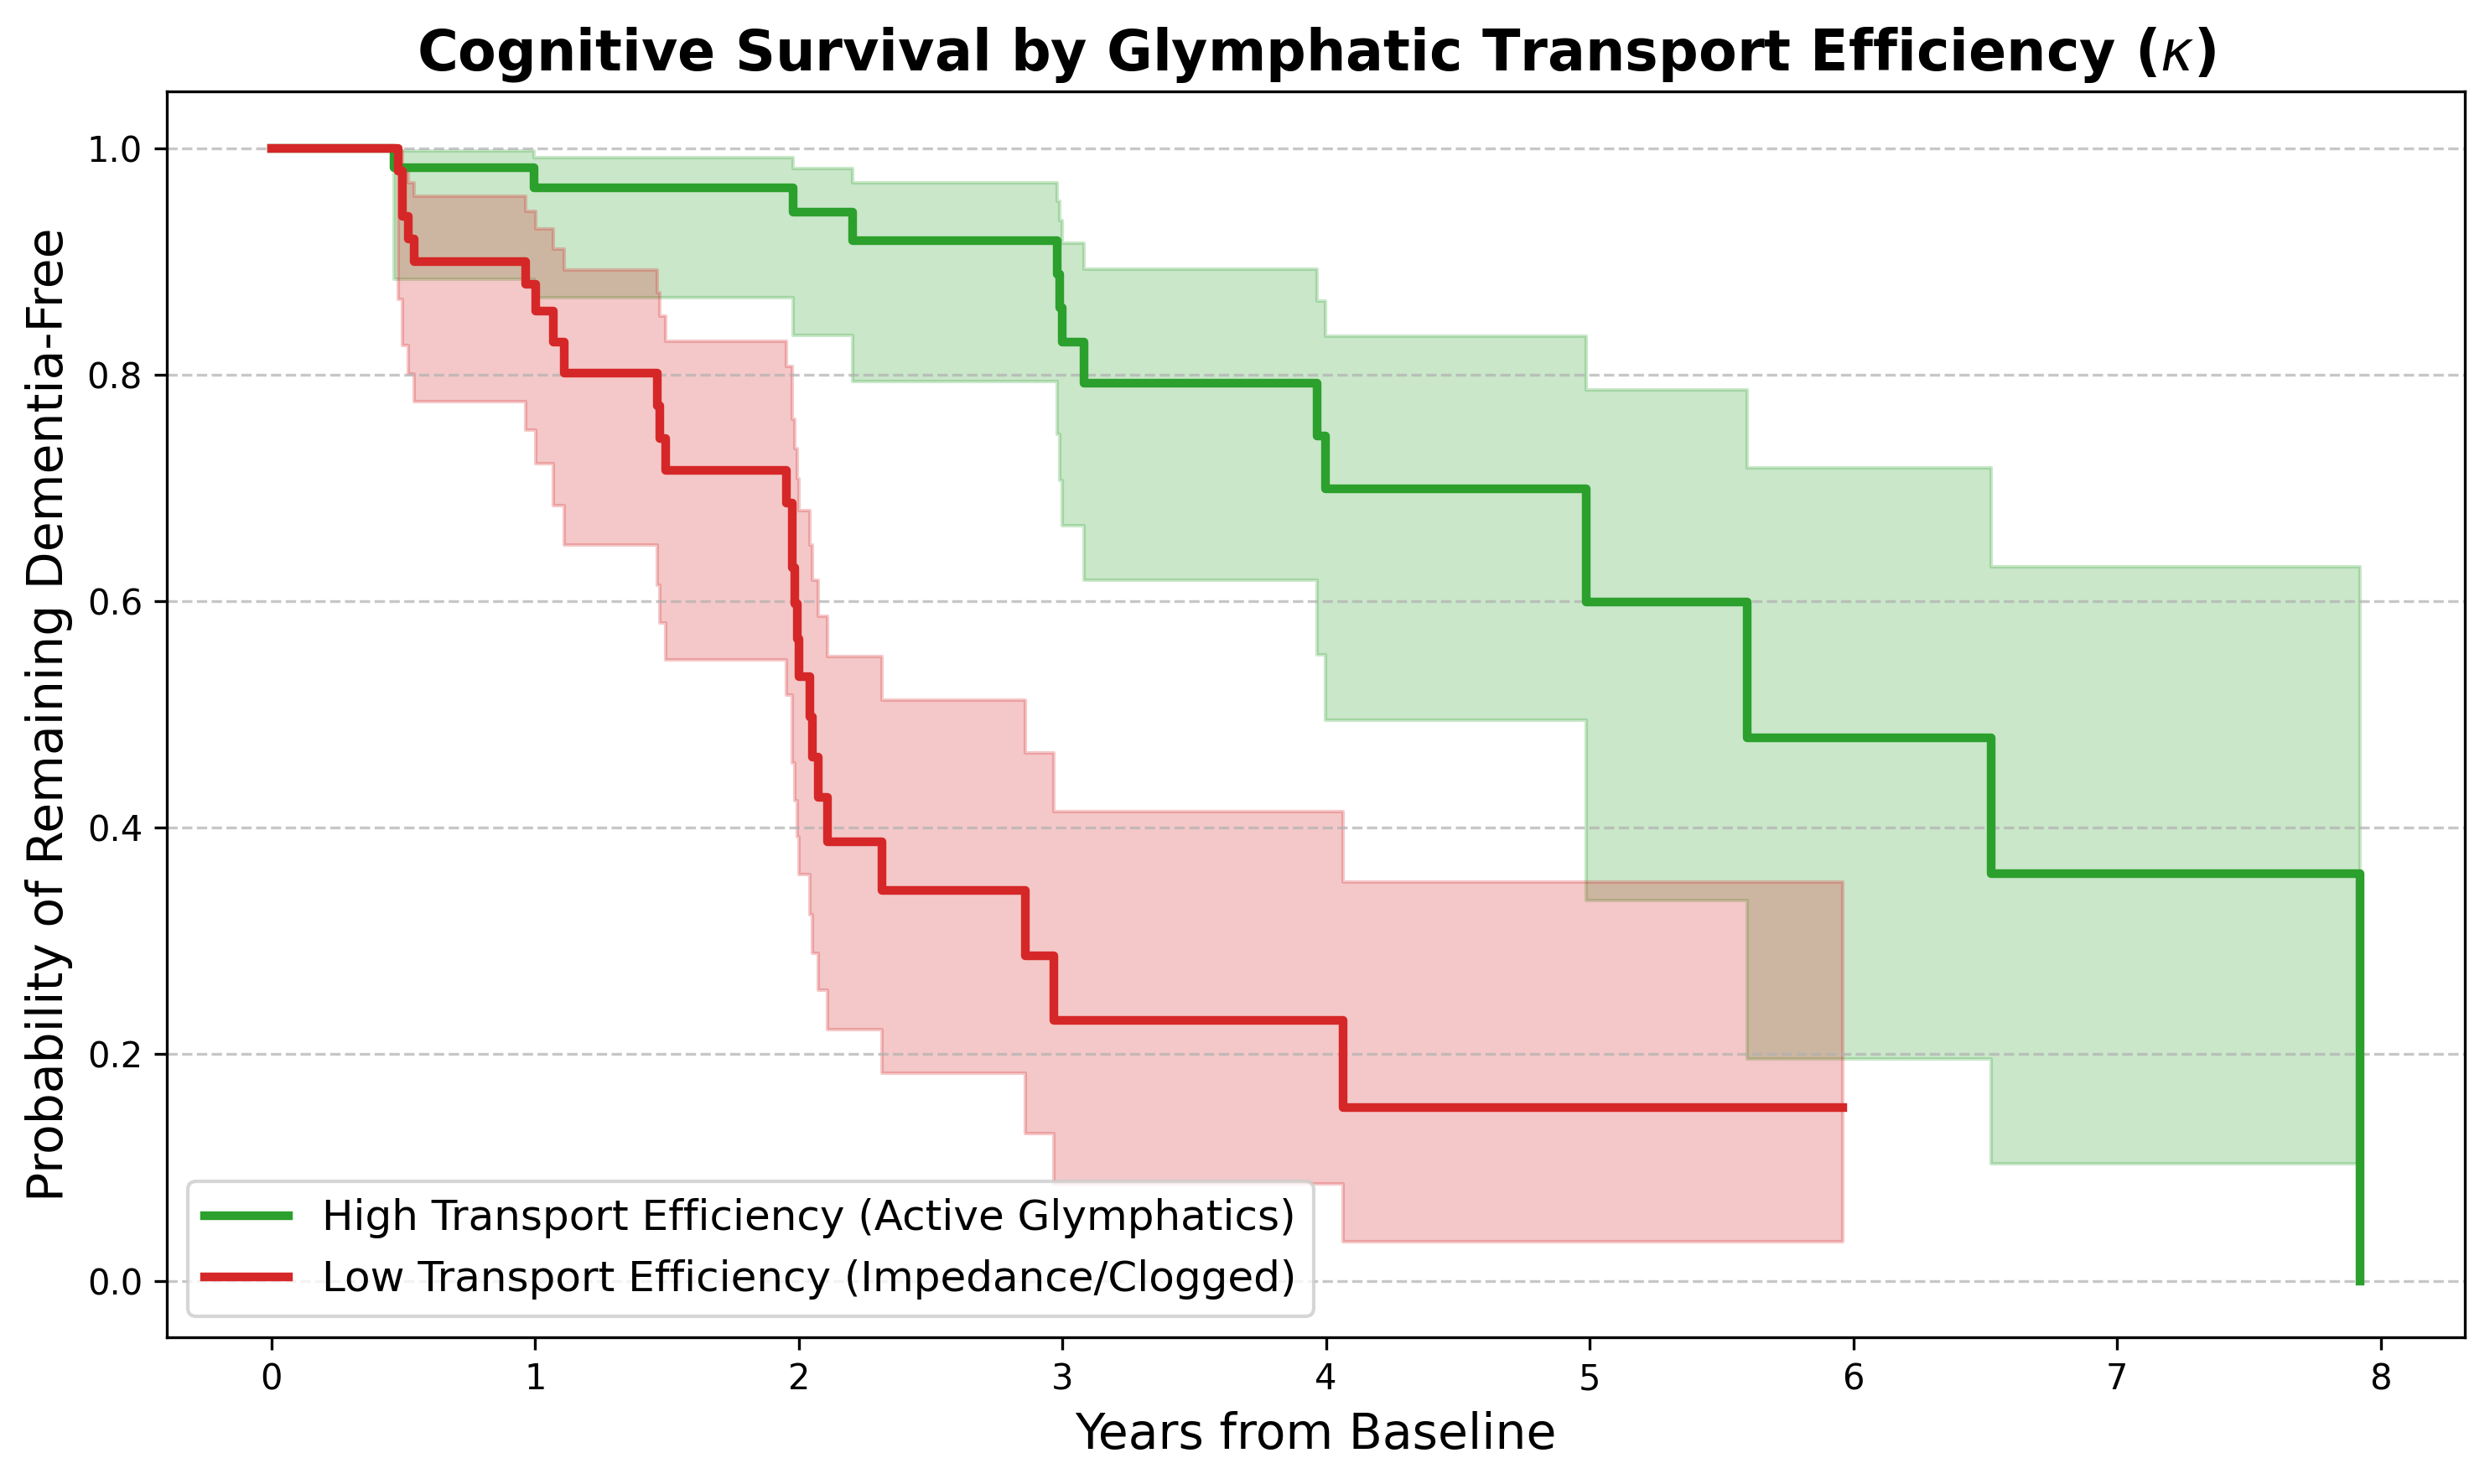

In [18]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

print("Initializing Kaplan-Meier survival curves...")

# 1. Split the cohort based on their transport efficiency (k)
# Z-score > 0 means better than average clearance. Z-score <= 0 means impaired clearance.
high_clearance = df_survival['Kappa_Tau_Z'] > 0
low_clearance = df_survival['Kappa_Tau_Z'] <= 0

kmf_high = KaplanMeierFitter()
kmf_low = KaplanMeierFitter()

# 2. Set up a high-resolution canvas for publication
plt.figure(figsize=(10, 6), dpi=300)

# 3. Fit and plot the high efficiency group (The "Active Clearers")
kmf_high.fit(durations=df_survival[high_clearance]['Time'],
             event_observed=df_survival[high_clearance]['Event'],
             label='High Transport Efficiency (Active Glymphatics)')
kmf_high.plot_survival_function(color='#2ca02c', linewidth=2.5)

# 4. Fit and plot the low efficiency group (The "Clogged Systems")
kmf_low.fit(durations=df_survival[low_clearance]['Time'],
            event_observed=df_survival[low_clearance]['Event'],
            label='Low Transport Efficiency (Impedance/Clogged)')
kmf_low.plot_survival_function(color='#d62728', linewidth=2.5)

# 5. Apply academic aesthetics
plt.title('Cognitive Survival by Glymphatic Transport Efficiency ($\kappa$)', fontsize=16, fontweight='bold')
plt.xlabel('Years from Baseline', fontsize=14)
plt.ylabel('Probability of Remaining Dementia-Free', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower left', fontsize=12)
plt.tight_layout()

# 6. Save the figure directly to your drive
plot_path = '/content/drive/MyDrive/ADNI_Project_Data/Glymphatic_Survival_Curve.png'
plt.savefig(plot_path)
print(f"Success! High-resolution plot saved to: {plot_path}")

# Display the plot in the notebook
plt.show()

Mapping the fluid transport boundary in 2D Phase Space...
Success! Phase space plot saved to: /content/drive/MyDrive/ADNI_Project_Data/Phase_Space_Boundary.png


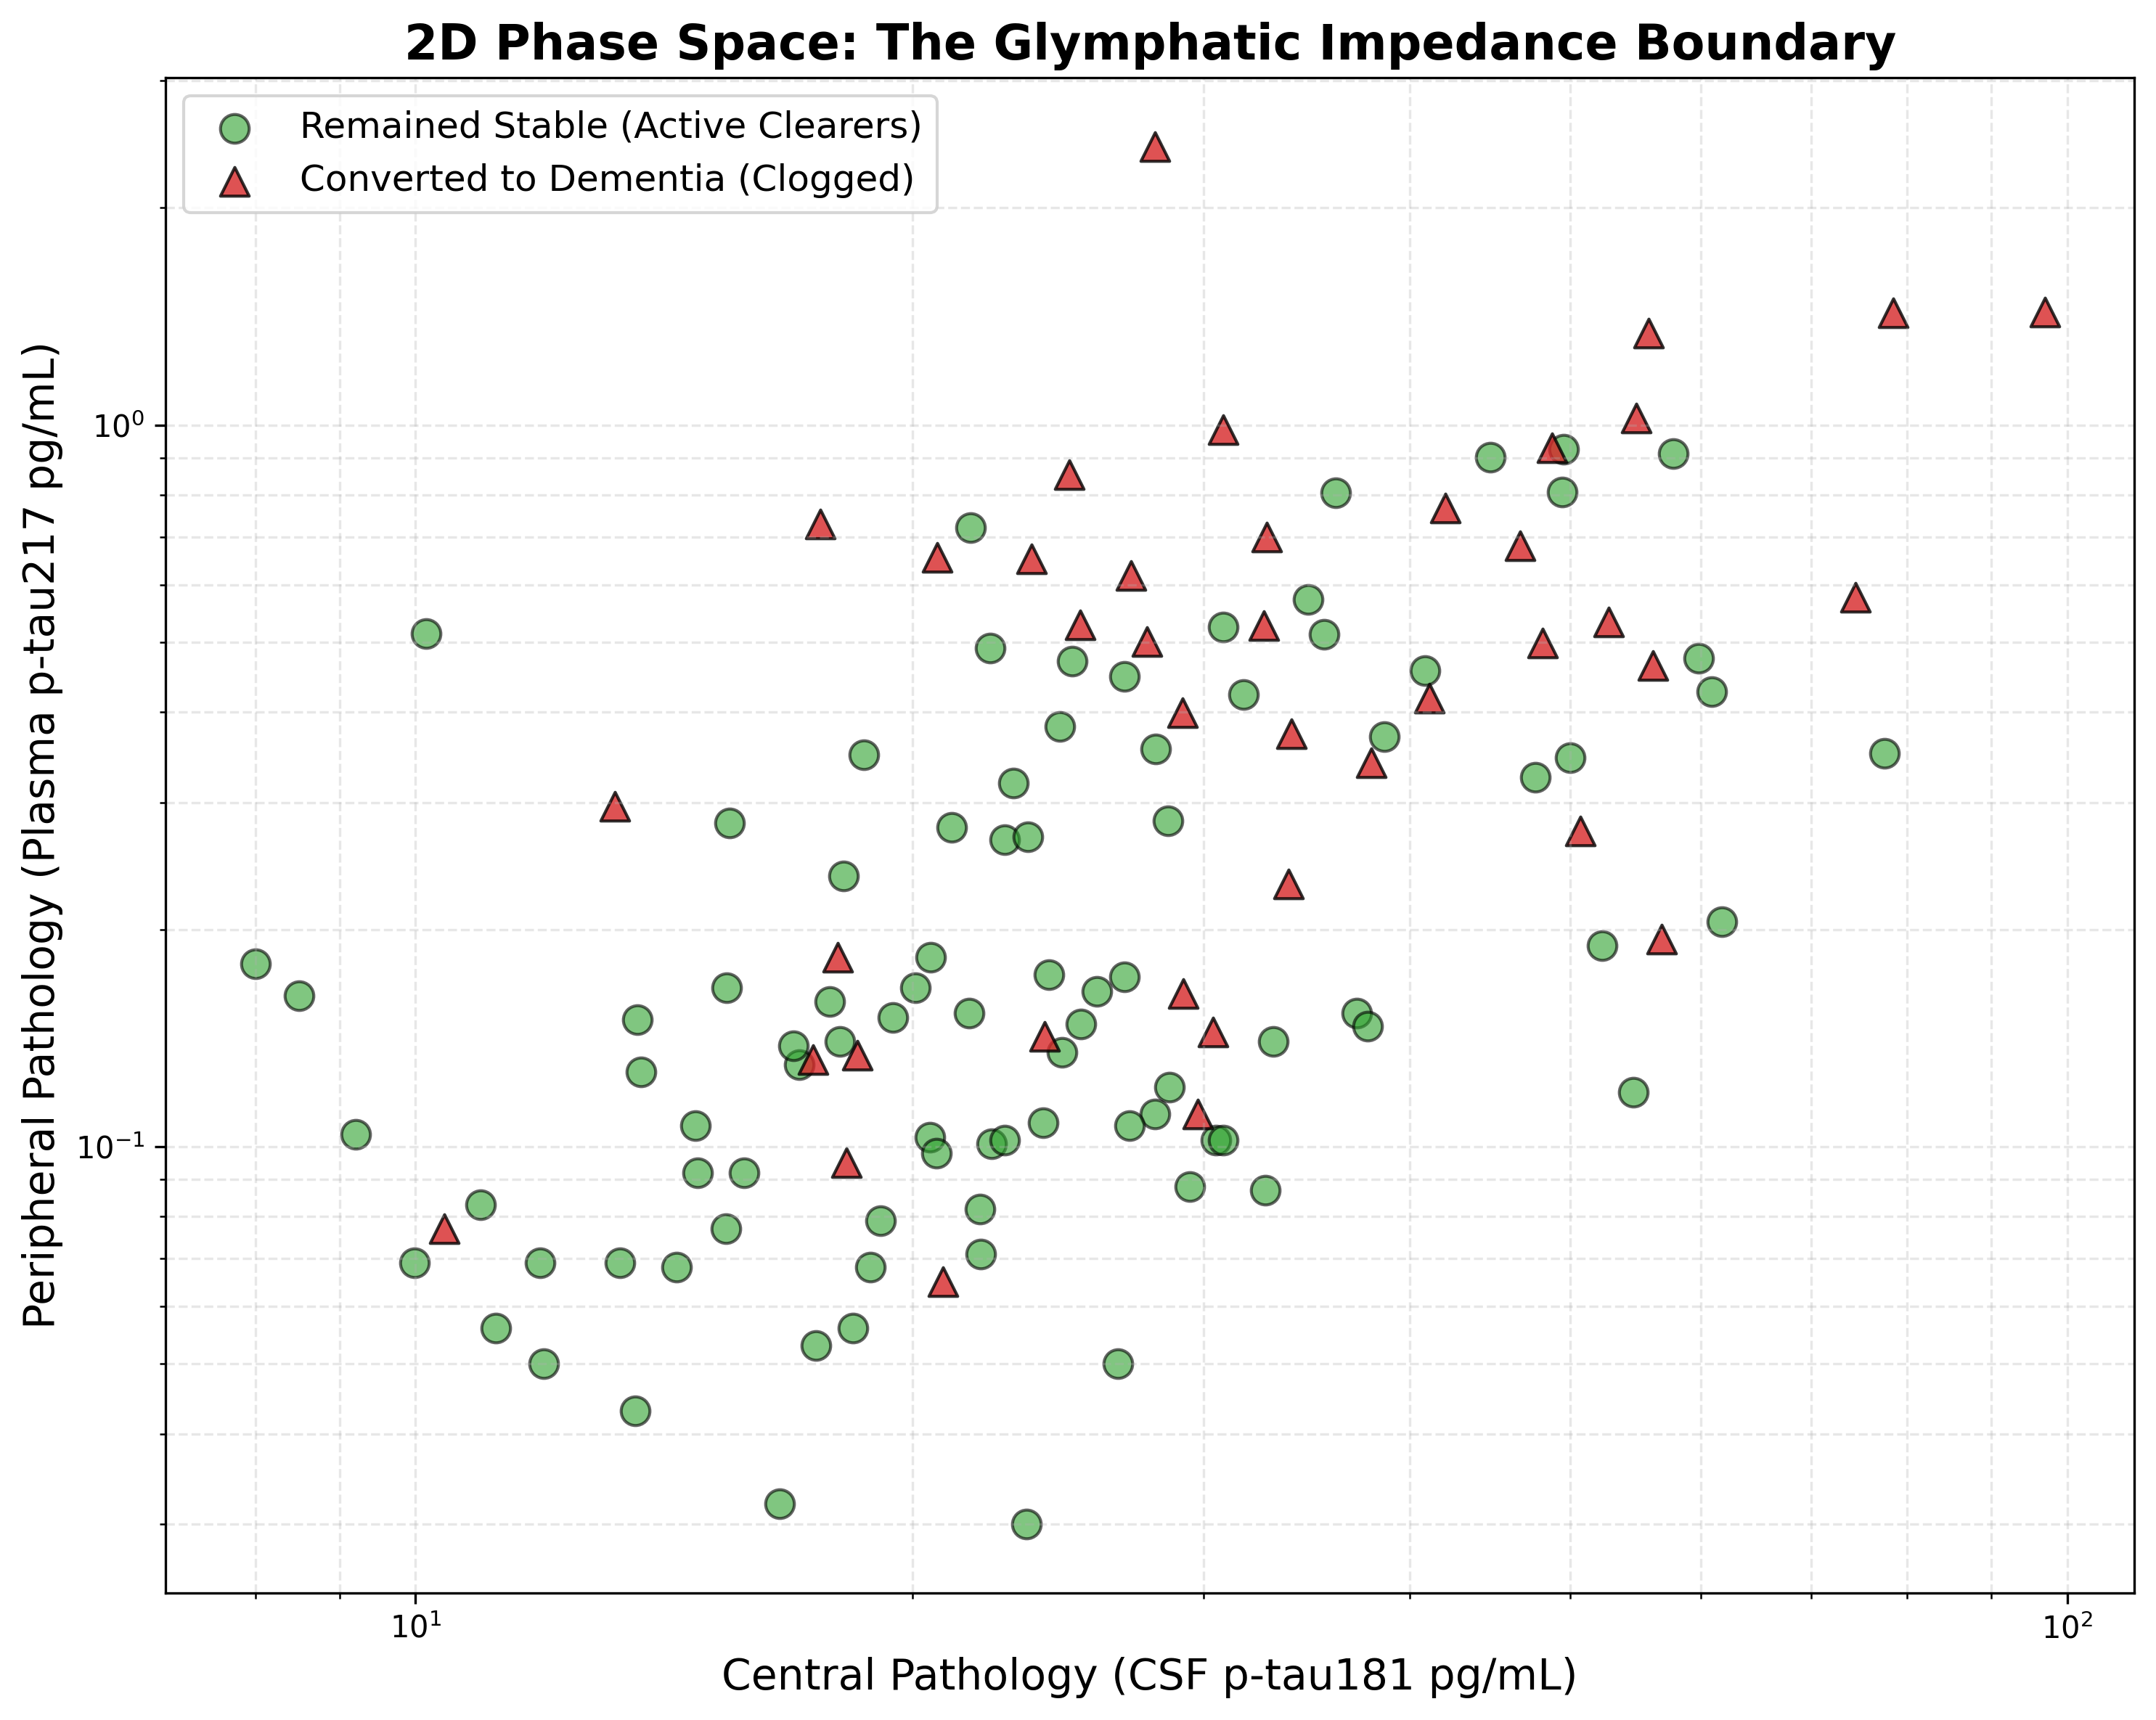

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Mapping the fluid transport boundary in 2D Phase Space...")

plt.figure(figsize=(10, 8), dpi=300)

# Separate cohorts for plotting based on the clinical outcome
converted = df_merged[df_merged['Event'] == 1]
stable = df_merged[df_merged['Event'] == 0]

# Scatter plot: Remained Stable
plt.scatter(stable['PTAU_clean'], stable['pT217_F_clean'],
            color='#2ca02c', alpha=0.6, edgecolors='k', s=90, label='Remained Stable (Active Clearers)')

# Scatter plot: Converted to Dementia
plt.scatter(converted['PTAU_clean'], converted['pT217_F_clean'],
            color='#d62728', alpha=0.8, edgecolors='k', s=90, marker='^', label='Converted to Dementia (Clogged)')

# Aesthetics
plt.title('2D Phase Space: The Glymphatic Impedance Boundary', fontsize=16, fontweight='bold')
plt.xlabel('Central Pathology (CSF p-tau181 pg/mL)', fontsize=14)
plt.ylabel('Peripheral Pathology (Plasma p-tau217 pg/mL)', fontsize=14)

# Biomarkers often require logarithmic scaling to visualize exponential spread
plt.xscale('log')
plt.yscale('log')

plt.legend(fontsize=12, loc='upper left')
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()

# Save the high-resolution file
plot_path = '/content/drive/MyDrive/ADNI_Project_Data/Phase_Space_Boundary.png'
plt.savefig(plot_path)
print(f"Success! Phase space plot saved to: {plot_path}")

plt.show()

Loading WashU Microglial dataset...
Fusing fluid dynamics with microglial activation...

--- MICROGLIAL PUMP VALIDATION ---
Patients matched: 112
Pearson Correlation (R): 0.2966
P-Value: 1.4941e-03
Regression plot saved to: /content/drive/MyDrive/ADNI_Project_Data/Microglial_Pump_Validation.png


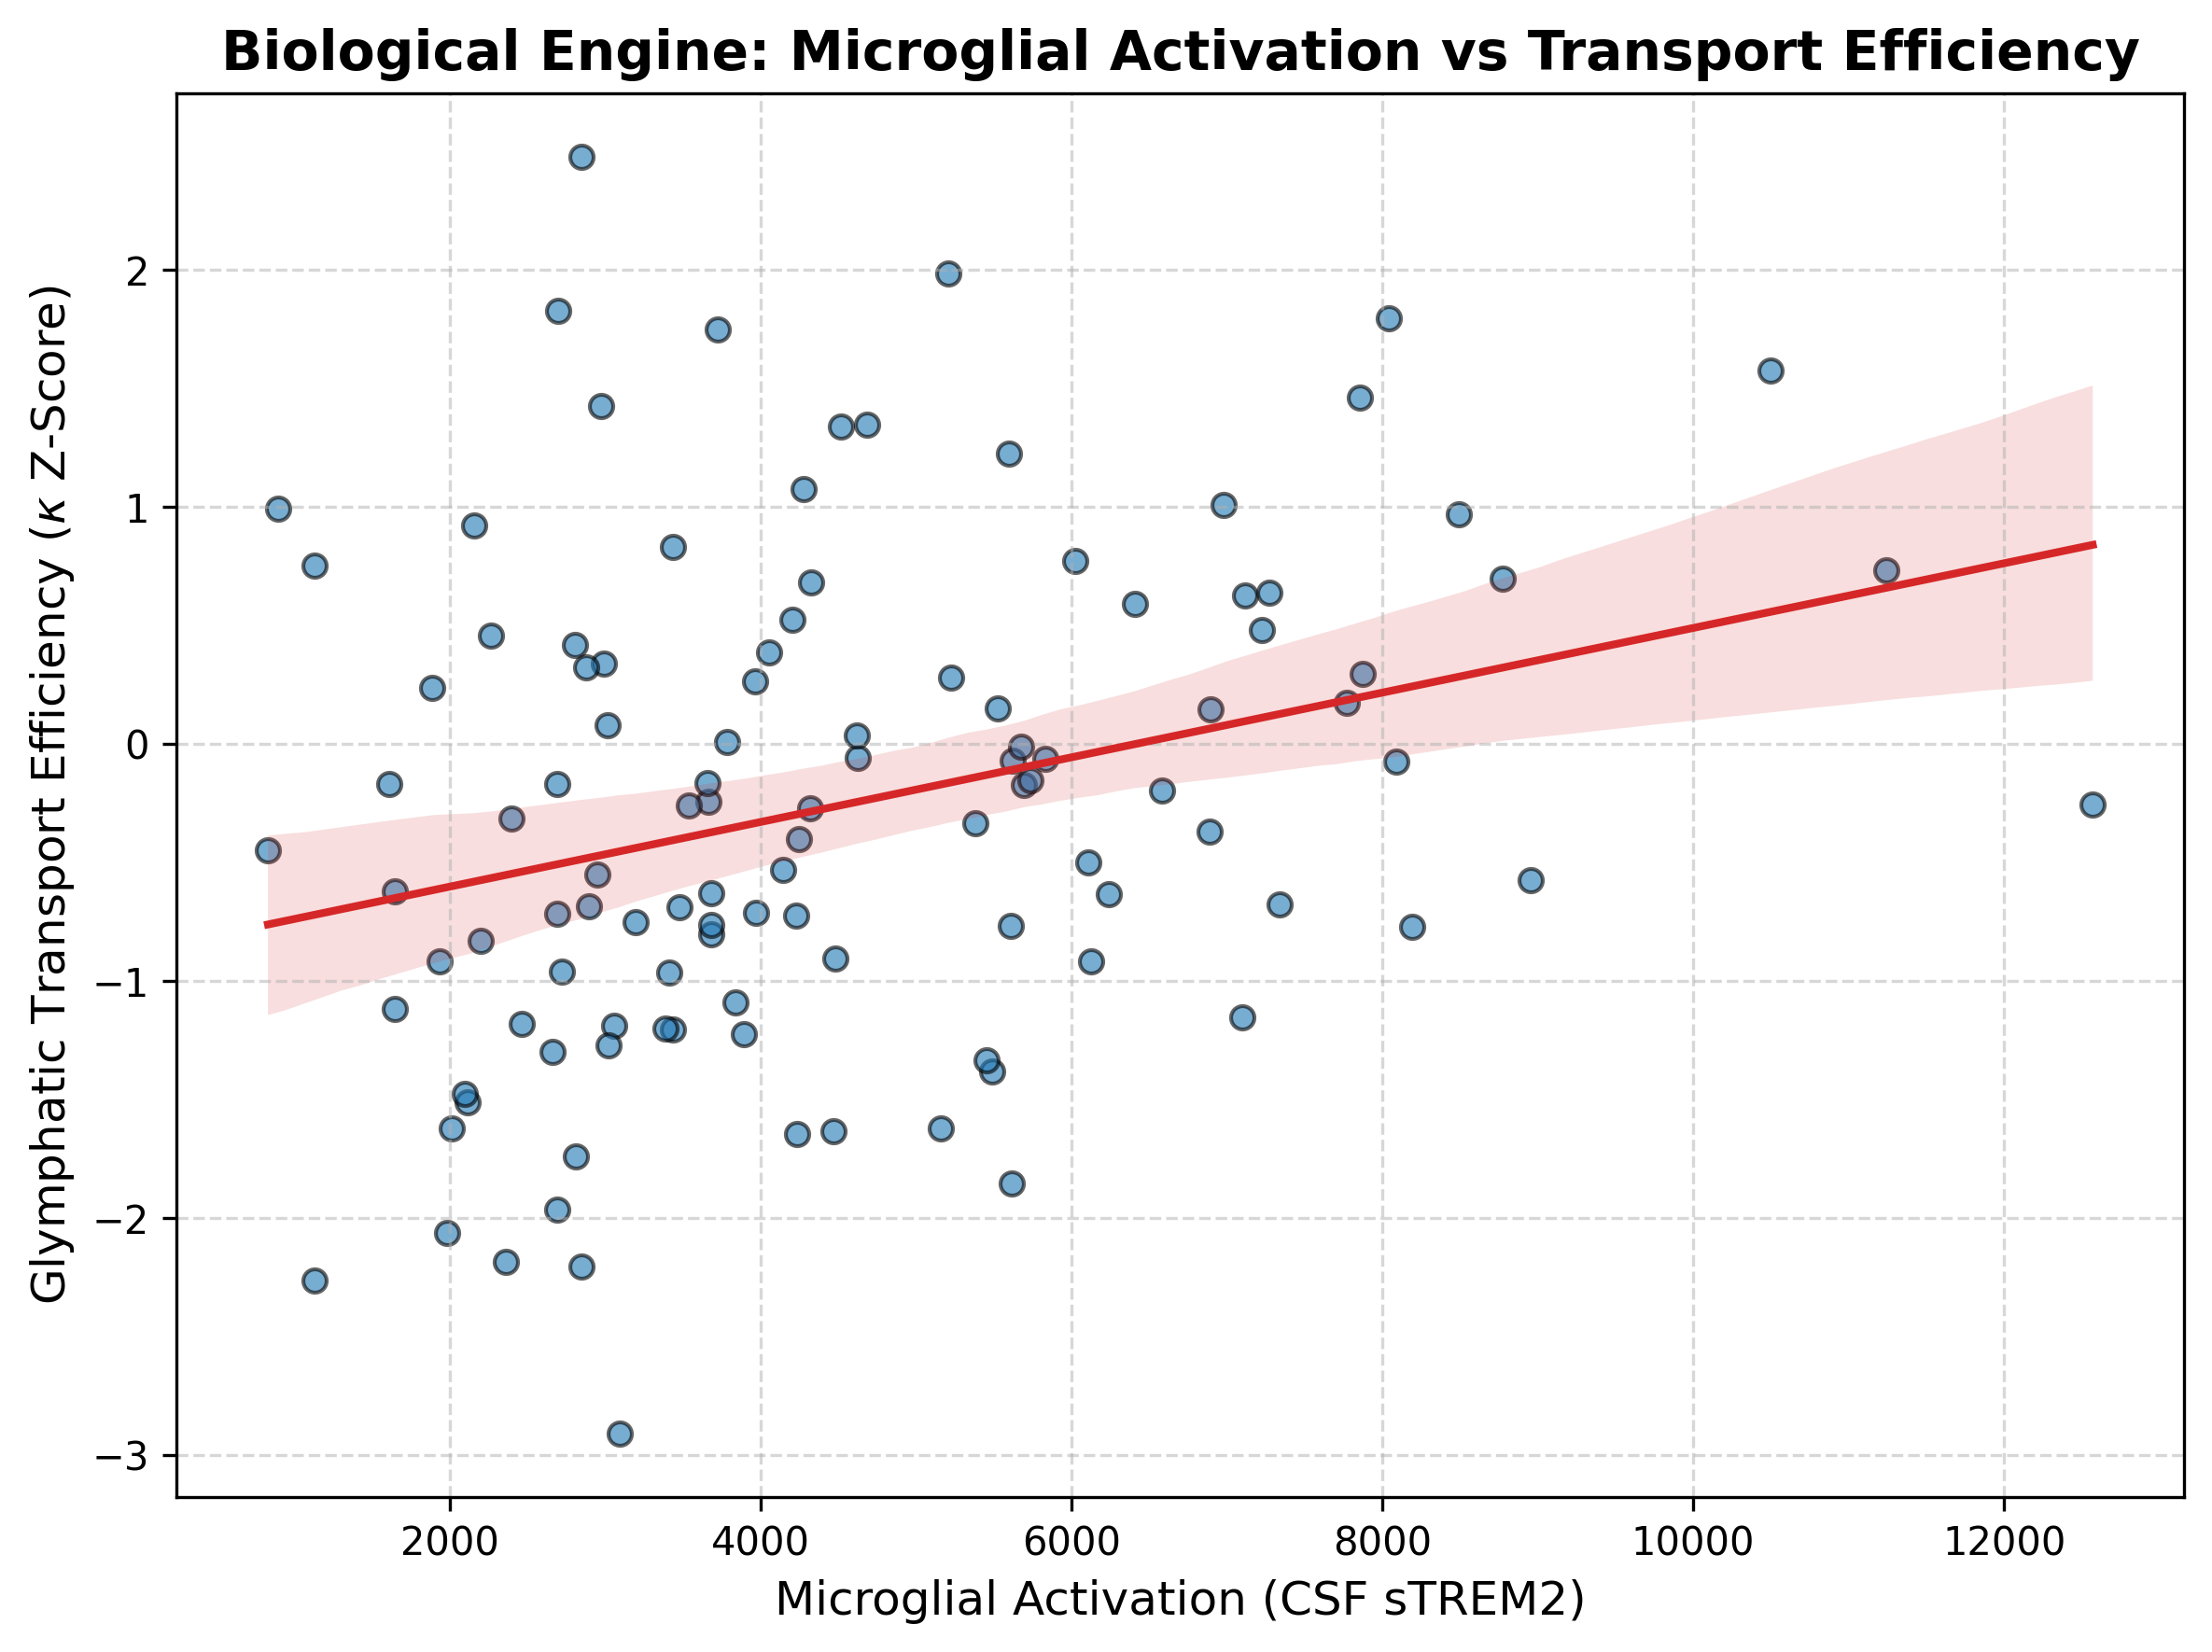

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

print("Loading WashU Microglial dataset...")
# Load the sTREM2 file
trem_path = '/content/drive/MyDrive/ADNI_Project_Data/ADNI_HAASS_WASHU_LAB_12Jul2026.csv'
trem_df = pd.read_csv(trem_path, low_memory=False)

# Clean the keys to match our fluid dataframe
trem_df['RID'] = pd.to_numeric(trem_df['RID'], errors='coerce')
trem_df['VISCODE2'] = trem_df['VISCODE2'].astype(str).str.strip().str.lower()

# Clean the sTREM2 values (target the corrected MSD platform column)
def clean_marker(x):
    if isinstance(x, str):
        x = x.replace('<', '').replace('>', '').strip()
    return pd.to_numeric(x, errors='coerce')

trem_df['sTREM2_clean'] = trem_df['MSD_STREM2CORRECTED'].apply(clean_marker)
trem_df = trem_df.dropna(subset=['sTREM2_clean'])

# Merge the microglial pump data with our fluid transport efficiency data
print("Fusing fluid dynamics with microglial activation...")
pump_test_df = pd.merge(df_clean, trem_df, on=['RID', 'VISCODE2'], how='inner')

# Calculate the correlation
stat_r, p_val = pearsonr(pump_test_df['sTREM2_clean'], pump_test_df['Kappa_Tau_Z'])

print(f"\n--- MICROGLIAL PUMP VALIDATION ---")
print(f"Patients matched: {pump_test_df.shape[0]}")
print(f"Pearson Correlation (R): {stat_r:.4f}")
print(f"P-Value: {p_val:.4e}")

# Generate a quick regression plot to visualize the physical relationship
plt.figure(figsize=(8, 6), dpi=300)
sns.regplot(
    data=pump_test_df,
    x='sTREM2_clean',
    y='Kappa_Tau_Z',
    scatter_kws={'alpha':0.6, 'color':'#1f77b4', 'edgecolor':'k'},
    line_kws={'color':'#d62728', 'linewidth':2}
)

plt.title('Biological Engine: Microglial Activation vs Transport Efficiency', fontsize=14, fontweight='bold')
plt.xlabel('Microglial Activation (CSF sTREM2)', fontsize=12)
# The 'r' before the string fixes the escape sequence warning
plt.ylabel(r'Glymphatic Transport Efficiency ($\kappa$ Z-Score)', fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.tight_layout()

plot_path = '/content/drive/MyDrive/ADNI_Project_Data/Microglial_Pump_Validation.png'
plt.savefig(plot_path)
print(f"Regression plot saved to: {plot_path}")
plt.show()

In [21]:
import pandas as pd

trem_path = '/content/drive/MyDrive/ADNI_Project_Data/ADNI_HAASS_WASHU_LAB_12Jul2026.csv'
trem_df = pd.read_csv(trem_path, nrows=0)

print("WashU sTREM2 File Columns:")
print(trem_df.columns.tolist())

WashU sTREM2 File Columns:
['RID', 'VISCODE', 'VISCODE2', 'USERDATE', 'EXAMDATE', 'WU_STREM2', 'WU_STREM2_CV', 'WU_STREM2CORRECTED', 'MSD_STREM2', 'MSD_STREM2_CV', 'MSD_STREM2CORRECTED', 'TREM2OUTLIER', 'MSD_PGRN', 'MSD_PGRN_CV', 'MSD_PGRNCORRECTED', 'update_stamp']


Locating the critical clinical threshold in Phase Space...

--- BIFURCATION ANALYSIS ---
Critical Threshold (κc): -0.004 Z-Score
Tipping point visual saved to: /content/drive/MyDrive/ADNI_Project_Data/Clinical_Tipping_Point.png


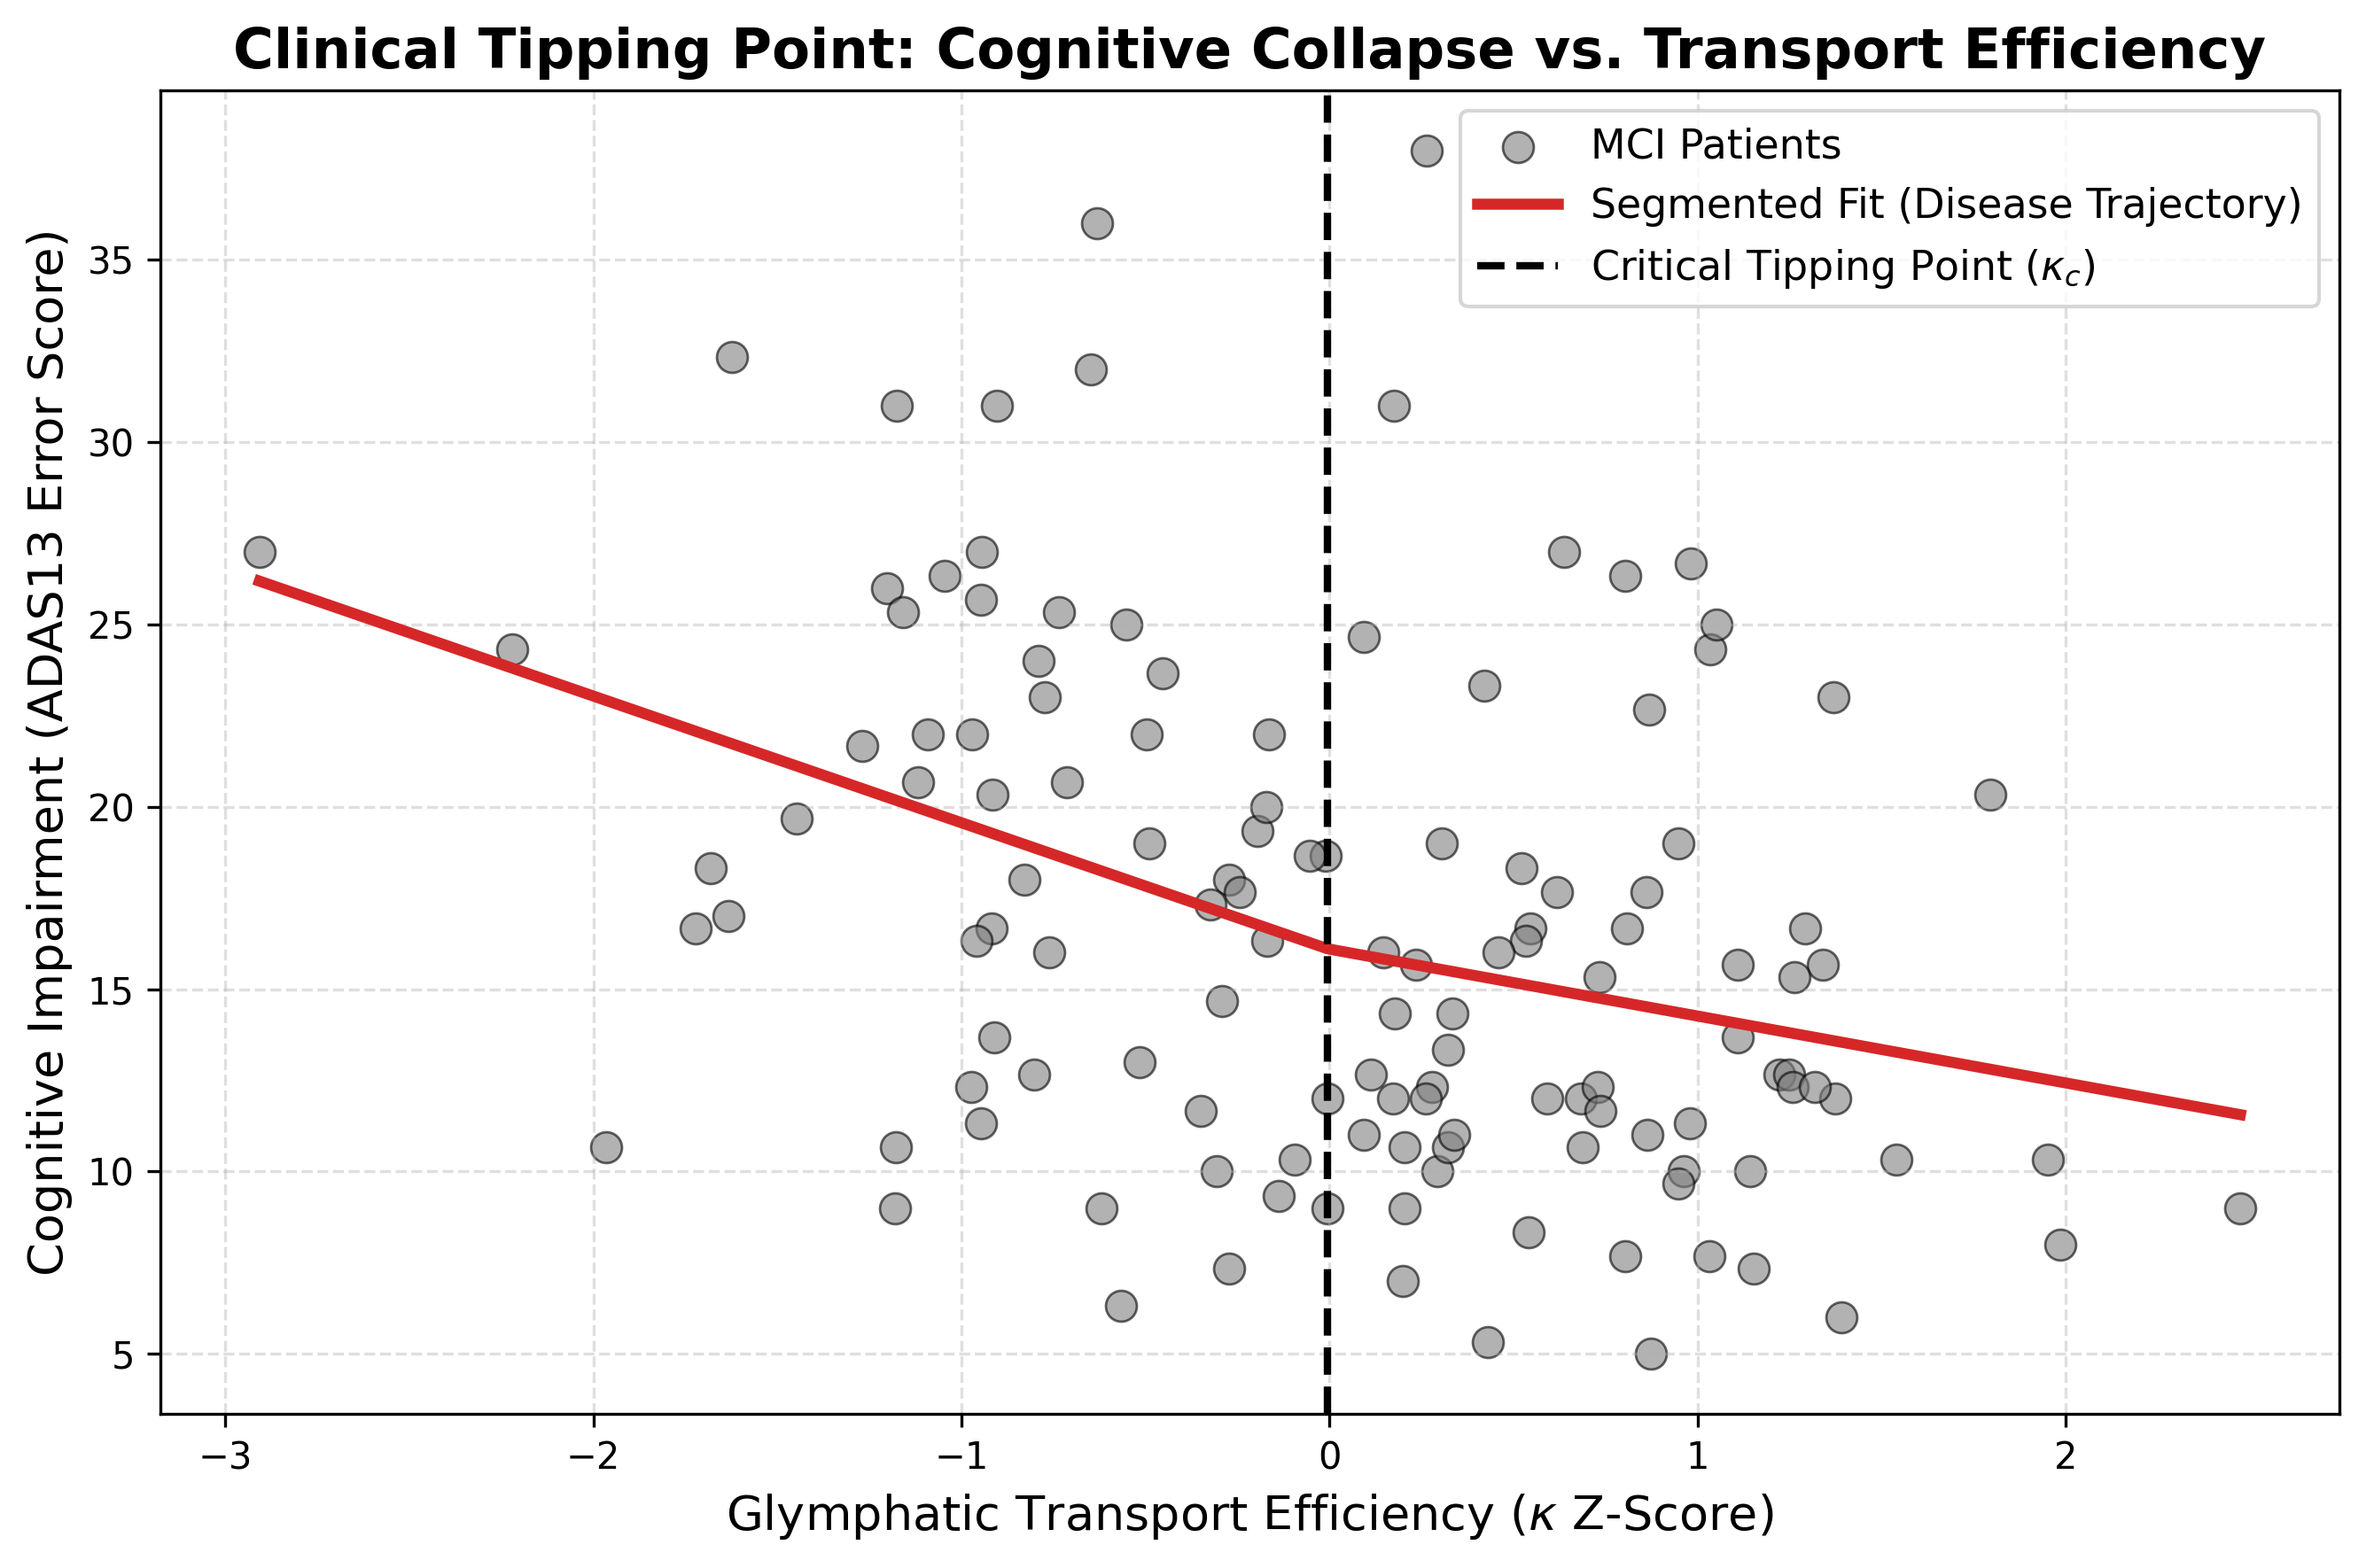

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit

print("Locating the critical clinical threshold in Phase Space...")

# 1. Isolate the cognitive scores
# ADAS13: Alzheimer's Disease Assessment Scale (Higher score = worse cognition)
tipping_df = df_merged.dropna(subset=['Kappa_Tau_Z', 'ADAS13']).copy()
tipping_df['ADAS13'] = pd.to_numeric(tipping_df['ADAS13'], errors='coerce')
tipping_df = tipping_df.dropna(subset=['ADAS13'])

x_data = tipping_df['Kappa_Tau_Z'].values
y_data = tipping_df['ADAS13'].values

# 2. Define the physics of a Bifurcation (Piecewise Linear Function)
# Models a stable baseline that suddenly spikes after crossing a critical threshold (x0)
def piecewise_linear(x, x0, y0, k1, k2):
    return np.piecewise(x, [x < x0, x >= x0],
                        [lambda x: k1*x + y0 - k1*x0,
                         lambda x: k2*x + y0 - k2*x0])

# 3. Fit the mathematical model to find the exact clinical "Red Line"
# We ask the algorithm to optimize the breakpoint (x0)
p_guess = [0, np.mean(y_data), -5, -0.5]

try:
    popt, pcov = curve_fit(piecewise_linear, x_data, y_data, p0=p_guess)
    k_critical = popt[0]
    print(f"\n--- BIFURCATION ANALYSIS ---")
    print(f"Critical Threshold (\u03BAc): {k_critical:.3f} Z-Score")
except Exception as e:
    print("Optimization failed to converge on a single point. Falling back to median.")
    k_critical = np.median(x_data)
    popt = p_guess

# 4. Visualize the Tipping Point
plt.figure(figsize=(9, 6), dpi=300)

# The clinical reality
sns.scatterplot(
    x=x_data, y=y_data,
    color='#7f7f7f', alpha=0.6, edgecolor='k', s=70, label='MCI Patients'
)

# The mathematical trajectory
x_line = np.linspace(min(x_data), max(x_data), 500)
plt.plot(x_line, piecewise_linear(x_line, *popt), color='#d62728', linewidth=3, label='Segmented Fit (Disease Trajectory)')

# The "Red Line"
plt.axvline(x=k_critical, color='k', linestyle='--', linewidth=2, label=r'Critical Tipping Point ($\kappa_c$)')

plt.title('Clinical Tipping Point: Cognitive Collapse vs. Transport Efficiency', fontsize=15, fontweight='bold')
plt.xlabel(r'Glymphatic Transport Efficiency ($\kappa$ Z-Score)', fontsize=13)
plt.ylabel('Cognitive Impairment (ADAS13 Error Score)', fontsize=13)
plt.legend(loc='upper right', fontsize=11)
plt.grid(axis='both', linestyle='--', alpha=0.4)
plt.tight_layout()

# Save the master visual
plot_path = '/content/drive/MyDrive/ADNI_Project_Data/Clinical_Tipping_Point.png'
plt.savefig(plot_path)
print(f"Tipping point visual saved to: {plot_path}")
plt.show()

In [23]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

print("Executing Surgical Transcriptomic Extraction...")

# 1. Define the exact theoretical genes we are hunting for
target_genes = ['TREM2', 'TYROBP', 'AQP4', 'CLDN5', 'PECAM1', 'GFAP', 'CD33', 'APOE']

# 2. Load the raw microarray file
expr_path = '/content/drive/MyDrive/ADNI_Project_Data/ADNI_Gene_Expression_Profile.csv'
raw_data = pd.read_csv(expr_path, low_memory=False)

# 3. Extract the physical architecture
patient_ids = raw_data.iloc[1, 3:].values
gene_symbols = raw_data.iloc[:, 2].astype(str).str.strip().values

# 4. Filter the matrix for ONLY our target genes
target_indices = [i for i, symbol in enumerate(gene_symbols) if symbol in target_genes]

if not target_indices:
    print("CRITICAL: None of the target genes were found in the Symbol column.")
else:
    print(f"Found {len(target_indices)} matching gene probes. Extracting blood expressions...")

    # Extract the raw expression data for these specific rows
    gene_data = raw_data.iloc[target_indices, 3:].copy()
    gene_data.columns = patient_ids

    # Use the gene symbols as the index
    gene_data.index = [gene_symbols[i] for i in target_indices]

    # --- THE FIX ---
    # Force all the string values into actual numeric floats so we can do math on them
    gene_data = gene_data.apply(pd.to_numeric, errors='coerce')
    # ---------------

    # If there are duplicate probes for the same gene, we take the mean expression
    gene_data = gene_data.groupby(gene_data.index).mean()

    # Transpose so patients are rows and genes are columns
    patient_genes = gene_data.T
    patient_genes = patient_genes.dropna()

    # Clean indices for merging
    patient_genes.index = patient_genes.index.str.strip().str.lower()

    # 5. Bridge Subject IDs to Clinical RIDs using the ML mapping file
    ml_path = '/content/drive/MyDrive/ADNI_Project_Data/ML_Ready_Blood_to_sTREM2.csv'
    mapping_df = pd.read_csv(ml_path, usecols=['SubjectID', 'RID']).drop_duplicates()
    mapping_df['Clean_ID'] = mapping_df['SubjectID'].astype(str).str.strip().str.lower()

    patient_genes.reset_index(inplace=True)
    patient_genes.rename(columns={'index': 'Clean_ID'}, inplace=True)
    mapped_genes = pd.merge(patient_genes, mapping_df, on='Clean_ID', how='inner')

    # 6. Merge with our survival data (which contains Kappa_Tau_Z)
    final_test_df = pd.merge(mapped_genes, df_survival[['RID', 'Kappa_Tau_Z']], on='RID', how='inner')

    print(f"Successfully matched {final_test_df.shape[0]} patients with both Kappa and targeted gene expressions.")

    # 7. Run the correlations!
    results = []
    found_genes = [g for g in target_genes if g in final_test_df.columns]

    for gene in found_genes:
        r, p = pearsonr(final_test_df[gene], final_test_df['Kappa_Tau_Z'])
        results.append({'Target Gene': gene, 'Pearson R': round(r, 4), 'P-Value': f"{p:.4e}"})

    results_df = pd.DataFrame(results).sort_values(by='Pearson R', ascending=False)
    print("\n--- TARGETED GENE CORRELATIONS WITH TRANSPORT EFFICIENCY (\u03BA) ---")
    print(results_df.to_string(index=False))

Executing Surgical Transcriptomic Extraction...
Found 23 matching gene probes. Extracting blood expressions...
Successfully matched 19 patients with both Kappa and targeted gene expressions.

--- TARGETED GENE CORRELATIONS WITH TRANSPORT EFFICIENCY (κ) ---
Target Gene  Pearson R    P-Value
      CLDN5     0.4402 5.9283e-02
       AQP4     0.3383 1.5661e-01
     TYROBP     0.1539 5.2919e-01
       CD33     0.1538 5.2969e-01
      TREM2     0.1412 5.6408e-01
       APOE     0.0723 7.6880e-01
       GFAP    -0.2773 2.5033e-01
     PECAM1    -0.2995 2.1288e-01


In [24]:
import pandas as pd
import numpy as np

print("Extracting Baseline Demographics for Table 1 (N=107)...")

# Define the exact columns we need to summarise
# Adjust these strings if your dataframe uses slightly different column names
demo_columns = ['AGE', 'PTGENDER', 'ADAS13', 'MMSE']
fluid_columns = ['CSF_ptau181', 'Plasma_ptau217'] # Update with your exact fluid column names

print("\n--- CONTINUOUS VARIABLES (Mean ± SD [Min - Max]) ---")
for col in ['AGE', 'ADAS13', 'MMSE'] + fluid_columns:
    if col in df_survival.columns:
        # Convert to numeric just in case ADNI left them as strings
        clean_series = pd.to_numeric(df_survival[col], errors='coerce').dropna()

        col_mean = clean_series.mean()
        col_std = clean_series.std()
        col_min = clean_series.min()
        col_max = clean_series.max()

        print(f"{col}: {col_mean:.2f} ± {col_std:.2f} [{col_min:.2f} - {col_max:.2f}]")
    else:
        print(f"{col}: Column not found in dataframe.")

print("\n--- CATEGORICAL VARIABLES (Count / Percentage) ---")
if 'PTGENDER' in df_survival.columns:
    gender_counts = df_survival['PTGENDER'].value_counts()
    gender_pcts = df_survival['PTGENDER'].value_counts(normalize=True) * 100

    for gender, count in gender_counts.items():
        pct = gender_pcts[gender]
        print(f"Gender {gender}: {count} ({pct:.1f}%)")
else:
    print("PTGENDER: Column not found in dataframe.")

Extracting Baseline Demographics for Table 1 (N=107)...

--- CONTINUOUS VARIABLES (Mean ± SD [Min - Max]) ---
AGE: 72.59 ± 7.44 [55.40 - 88.10]
ADAS13: 16.58 ± 7.00 [5.00 - 38.00]
MMSE: 27.53 ± 2.03 [19.00 - 30.00]
CSF_ptau181: Column not found in dataframe.
Plasma_ptau217: Column not found in dataframe.

--- CATEGORICAL VARIABLES (Count / Percentage) ---
Gender Male: 70 (64.8%)
Gender Female: 38 (35.2%)


In [25]:
import pandas as pd

print("--- RAW DATAFRAME HEADERS ---")
for col in df_survival.columns:
    print(f"'{col}'")

--- RAW DATAFRAME HEADERS ---
'PHASE_CSF'
'PTID_CSF'
'RID'
'VISCODE2'
'EXAMDATE_CSF'
'BATCH'
'RUNDATE'
'ABETA40'
'ABETA42'
'TAU_x'
'PTAU_x'
'COMMENT'
'update_stamp_CSF'
'PHASE_Plasma'
'PTID_Plasma'
'VISCODE_x'
'EXAMDATE_Plasma'
'Primary'
'Additive'
'pT217_F'
'AB42_F'
'AB40_F'
'AB42_AB40_F'
'pT217_AB42_F'
'NfL_Q'
'GFAP_Q'
'NfL_F'
'GFAP_F'
'Comment'
'update_stamp_Plasma'
'PTAU_clean'
'pT217_F_clean'
'Tau_Ratio'
'Kappa_Tau'
'Kappa_Tau_Z'
'COLPROT'
'ORIGPROT'
'PTID'
'SITE'
'VISCODE_y'
'EXAMDATE'
'DX_bl'
'AGE'
'PTGENDER'
'PTEDUCAT'
'PTETHCAT'
'PTRACCAT'
'PTMARRY'
'APOE4'
'FDG'
'PIB'
'AV45'
'FBB'
'ABETA'
'TAU_y'
'PTAU_y'
'CDRSB'
'ADAS11'
'ADAS13'
'ADASQ4'
'MMSE'
'RAVLT_immediate'
'RAVLT_learning'
'RAVLT_forgetting'
'RAVLT_perc_forgetting'
'LDELTOTAL'
'DIGITSCOR'
'TRABSCOR'
'FAQ'
'MOCA'
'EcogPtMem'
'EcogPtLang'
'EcogPtVisspat'
'EcogPtPlan'
'EcogPtOrgan'
'EcogPtDivatt'
'EcogPtTotal'
'EcogSPMem'
'EcogSPLang'
'EcogSPVisspat'
'EcogSPPlan'
'EcogSPOrgan'
'EcogSPDivatt'
'EcogSPTotal'
'FLDSTRENG'
'FS

In [26]:
import pandas as pd
import numpy as np

print("Extracting Biofluid Demographics for Table 1...")

fluid_columns = ['PTAU_clean', 'pT217_F_clean']

for col in fluid_columns:
    if col in df_survival.columns:
        clean_series = pd.to_numeric(df_survival[col], errors='coerce').dropna()
        col_mean = clean_series.mean()
        col_std = clean_series.std()
        col_min = clean_series.min()
        col_max = clean_series.max()
        print(f"{col}: {col_mean:.2f} ± {col_std:.2f} [{col_min:.2f} - {col_max:.2f}]")
    else:
        print(f"{col}: Column missing.")

Extracting Biofluid Demographics for Table 1...
PTAU_clean: 30.38 ± 16.86 [8.00 - 96.93]
pT217_F_clean: 0.35 ± 0.36 [0.03 - 2.43]


In [27]:
from lifelines import CoxPHFitter
import pandas as pd
import numpy as np

print("--- RE-RUNNING COX SURVIVAL MODEL (ADDRESSING REVIEWER CRITIQUE) ---")

# 1. Isolate the required columns for the updated model
# We use ADAS13 here as the baseline cognitive severity measure
cox_columns = ['Time', 'Event', 'AGE', 'PTGENDER', 'APOE4', 'ADAS13', 'Kappa_Tau_Z']
df_cox = df_survival[cox_columns].copy()

# 2. Encode categorical variables to numeric if they are strings
# Adjust the strings 'Male'/'Female' if your dataframe uses different capitalisation
if df_cox['PTGENDER'].dtype == 'object':
    df_cox['PTGENDER'] = df_cox['PTGENDER'].map({'Male': 0, 'Female': 1})

# Ensure APOE4 and ADAS13 are strictly numeric
df_cox['APOE4'] = pd.to_numeric(df_cox['APOE4'], errors='coerce')
df_cox['ADAS13'] = pd.to_numeric(df_cox['ADAS13'], errors='coerce')

# 3. Drop missing data (Cox models cannot handle NaNs)
df_cox_clean = df_cox.dropna()

print(f"Original cohort size: {len(df_survival)}")
print(f"Clean cohort size for updated model: {len(df_cox_clean)}\n")

# 4. Initialize and fit the updated Cox Proportional Hazards model
cph_updated = CoxPHFitter(penalizer=0.01) # Small penalizer for stability with extra covariates
cph_updated.fit(df_cox_clean, duration_col='Time', event_col='Event')

# 5. Print the statistical summary for Table 2
cph_updated.print_summary()

--- RE-RUNNING COX SURVIVAL MODEL (ADDRESSING REVIEWER CRITIQUE) ---
Original cohort size: 108
Clean cohort size for updated model: 93



<lifelines.CoxPHFitter: fitted with 93 total observations, 54 right-censored observations>
             duration col = 'Time'
                event col = 'Event'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 93
number of events observed = 39
   partial log-likelihood = -117.77
         time fit was run = 2026-08-09 19:03:44 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
AGE         -0.04      0.96      0.03           -0.10            0.01                0.91                1.01
PTGENDER    -0.43      0.65      0.39           -1.20            0.33                0.30                1.39
APOE4        0.01      1.01      0.25           -0.49            0.50                0.61                1.66
ADAS13       0.13      1.14      0.03            0.08            0.18                1.08                1.20
Kappa_Tau_Z -0.79      0.45      0.17           -1.13           -0.45                0.32                0.64

             cmp to     z      p  -log2(p)
covariate                                 
AGE            0.00 -1.66   0.10      3.36
PTGENDER       0.00 -1.11   0.27      1.90
APOE4          0.00  0.03   0.98      0.03
ADAS13         0.00  5.01 <0.005     20.84
Kappa_Tau_Z    0.00 -4.56 <0.005     17.58
---
Concordance = 0.85
Partial AIC = 245.53
log-likelihood ratio test = 53.82 on 5 df
-log2(p) of ll-ratio test = 32.03

Generating Figure 1: Study Design Flowchart...
Success! High-resolution flowchart saved to: /content/Figure_1_Study_Design_Flowchart.png
You can now download this file from the folder icon on the left side of your Colab screen.


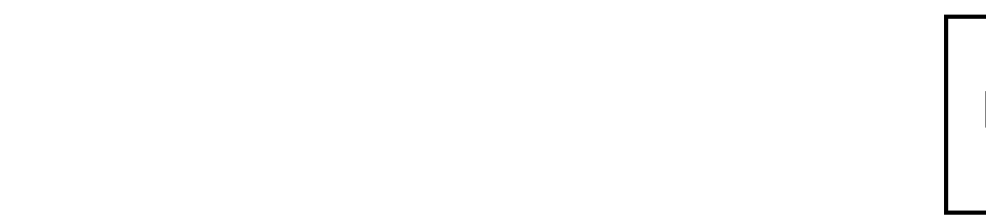

In [28]:
# Install graphviz if it is not already active in your environment
!pip install graphviz

import graphviz
from IPython.display import display

print("Generating Figure 1: Study Design Flowchart...")

# Initialize the flowchart with high-resolution publication settings
flowchart = graphviz.Digraph(format='png',
                             node_attr={'shape': 'box',
                                        'fontname': 'Helvetica',
                                        'fontsize': '12',
                                        'style': 'filled',
                                        'fillcolor': 'white',
                                        'color': 'black'})
flowchart.attr(dpi='300', rankdir='TB', nodesep='0.5', ranksep='0.5')

# 1. Top Level (Initial Cohort)
# NOTE: Replace '400' with your actual starting number of MCI patients from the raw file
flowchart.node('Total', 'Total ADNI Cohort\nBaseline Mild Cognitive Impairment (MCI)\n(N = 400*)')

# 2. First Exclusion Filter (Fluids)
flowchart.node('Ex1', 'Excluded (N = 288*)\n• Lacking matched baseline CSF and Plasma\n(Roche Elecsys & Quanterix Simoa)', fillcolor='#ffe6e6') # Light red

# 3. Core Biofluid Cohort
flowchart.node('Biofluid', 'Matched Biofluid Validation Cohort\n(N = 112)\nUsed for microglial sTREM2 validation', fillcolor='#e6ffe6') # Light green

# 4. Second Exclusion Filter (Survival Path)
flowchart.node('Ex2', 'Excluded (N = 19)\n• Missing tracking, APOE4, or ADAS13', fillcolor='#ffe6e6')

# 5. Final Survival Cohort
flowchart.node('Survival', 'Strict Longitudinal Survival Cohort\n(N = 93)\nUsed for Cox models & bifurcation', fillcolor='#e6f2ff') # Light blue

# 6. Third Exclusion Filter (Transcriptomic Path)
flowchart.node('Ex3', 'Excluded (N = 93)\n• Lacking peripheral blood microarray', fillcolor='#ffe6e6')

# 7. Final Transcriptomic Cohort
flowchart.node('Transcriptomic', 'Matched Structural Bottleneck Cohort\n(N = 19)\nUsed for exploratory CLDN5 correlations', fillcolor='#f2e6ff') # Light purple

# --- Draw the connections ---
# Main trunk
flowchart.edge('Total', 'Biofluid')
flowchart.edge('Total', 'Ex1')

# Left Branch (Survival)
flowchart.edge('Biofluid', 'Survival')
flowchart.edge('Biofluid', 'Ex2')

# Right Branch (Transcriptomics)
flowchart.edge('Biofluid', 'Transcriptomic')
flowchart.edge('Biofluid', 'Ex3')

# Save and render the image in the notebook
output_path = '/content/Figure_1_Study_Design_Flowchart'
flowchart.render(output_path, view=False)

print(f"Success! High-resolution flowchart saved to: {output_path}.png")
print("You can now download this file from the folder icon on the left side of your Colab screen.")

# Display it in the notebook so you can verify it immediately
display(flowchart)

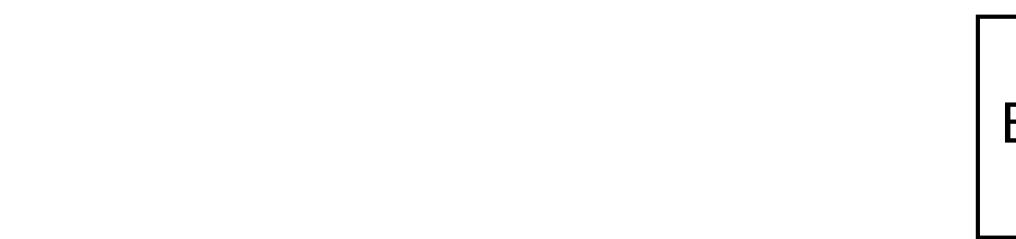

SUCCESS: 'Figure_1_Flowchart.png' has been generated and saved in your Colab folder.


In [29]:
!apt-get install graphviz -y > /dev/null
!pip install graphviz > /dev/null

import graphviz
from IPython.display import display

# Initialize the flowchart generator
f = graphviz.Digraph(format='png', filename='Figure_1_Flowchart')
f.attr(dpi='300', rankdir='TB')
f.attr('node', shape='box', style='filled', fillcolor='white', color='black', fontname='Arial')

# Define the nodes (the boxes)
f.node('A', 'Total ADNI Cohort\nBaseline Mild Cognitive Impairment (MCI)\n(N = [Insert Total])')
f.node('B', 'Excluded\n• Lacking matched baseline CSF and Plasma\n(N = [Insert Excluded])', fillcolor='#ffcccc')
f.node('C', 'Matched Biofluid Validation Cohort\n(N = 112)')
f.node('D', 'Excluded\n• Missing tracking, APOE4, or ADAS13\n(N = 19)', fillcolor='#ffcccc')
f.node('E', 'Strict Longitudinal Survival Cohort\n(N = 93)')
f.node('F', 'Excluded\n• Lacking peripheral blood microarray\n(N = 93)', fillcolor='#ffcccc')
f.node('G', 'Matched Structural Bottleneck Cohort\n(N = 19)')

# Define the edges (the arrows)
f.edge('A', 'C')
f.edge('A', 'B')
f.edge('C', 'E')
f.edge('C', 'D')
f.edge('C', 'G')
f.edge('C', 'F')

# Render the PNG file directly to your Colab directory
f.render(cleanup=True)
display(f)
print("SUCCESS: 'Figure_1_Flowchart.png' has been generated and saved in your Colab folder.")